# Google Stock Forecasting — PyTorch RNN/LSTM

This notebook evaluates recurrent neural networks for next-day GOOG forecasting, moving from direct price prediction to return-based forecasting and then adding broader market context from QQQ, SPY, and VIX.

> **Repository note:** saved outputs from the original Kaggle run are preserved. One later explanatory markdown sentence contains stale directional percentages; the final printed result table is treated as authoritative in this repository.

> The notebook was developed on Kaggle and contains Kaggle input paths. It also refreshes market data with `yfinance`, so a fresh rerun can produce different values from the saved outputs.


## Import Libraries & Setup

In [1]:
import random
import time
import warnings
from datetime import datetime
import os
import yfinance as yf
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


## Load the Base Dataset

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The original GOOG CSV is loaded from the Kaggle input dataset and sorted by date.</li>
<li style="margin:4px 0;">The initial file is kept as a reproducible starting point before the live market-data update.</li>
</ul>
</div>

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/kianazesmaeili/google-stock-dataset/Google.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/kianazesmaeili/google-stock-dataset/Google.csv')

df.head()

,Unnamed: 0,open,high,low,close,adjclose,volume,ticker
0,2016-01-04,37.150002,37.202999,36.562901,37.091999,37.091999,65456000,GOOG
1,2016-01-05,37.322498,37.599998,36.931999,37.129002,37.129002,39014000,GOOG
2,2016-01-06,36.500000,37.359001,36.445999,37.181000,37.181000,38940000,GOOG
3,2016-01-07,36.515499,36.924999,35.952999,36.319500,36.319500,59274000,GOOG
4,2016-01-08,36.572498,36.661499,35.650002,35.723499,35.723499,49018000,GOOG


In [5]:
df = df.rename(columns={"Unnamed: 0": "Date"})

df["Date"] = pd.to_datetime(df["Date"])

df = (
    df
    .sort_values("Date")
    .reset_index(drop=True)
)

df.head()

,Date,open,high,low,close,adjclose,volume,ticker
0,2016-01-04,37.150002,37.202999,36.562901,37.091999,37.091999,65456000,GOOG
1,2016-01-05,37.322498,37.599998,36.931999,37.129002,37.129002,39014000,GOOG
2,2016-01-06,36.500000,37.359001,36.445999,37.181000,37.181000,38940000,GOOG
3,2016-01-07,36.515499,36.924999,35.952999,36.319500,36.319500,59274000,GOOG
4,2016-01-08,36.572498,36.661499,35.650002,35.723499,35.723499,49018000,GOOG


In [6]:
print("Dataset shape:", df.shape)
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

df.info()

Dataset shape: (2113, 8)
Start date: 2016-01-04 00:00:00
End date: 2024-05-24 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2113 entries, 0 to 2112
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2113 non-null   datetime64[ns]
 1   open      2113 non-null   float64       
 2   high      2113 non-null   float64       
 3   low       2113 non-null   float64       
 4   close     2113 non-null   float64       
 5   adjclose  2113 non-null   float64       
 6   volume    2113 non-null   int64         
 7   ticker    2113 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 132.2+ KB


## Update GOOG Market Data

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Yahoo Finance is used to refresh GOOG history from January 2016 to the latest available trading day.</li>
<li style="margin:4px 0;">Only Date, Open, High, Low, Close, and Volume are retained for the forecasting workflow.</li>
<li style="margin:4px 0;">The current market price is also saved separately as a simple reference.</li>
</ul>
</div>

In [7]:
ticker = yf.Ticker("GOOG")
live_price = ticker.history(period="1d")["Close"].iloc[-1]

print("The current price is:", live_price)

live_price_df = pd.DataFrame({
    "Timestamp": [datetime.now()],
    "Price": [live_price]
})

live_price_df.to_csv(
    "live_price.csv",
    index=False
)

start_date = "2016-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")

historical_data = yf.download(
    "GOOG",
    start=start_date,
    end=end_date,
    progress=False
)

historical_data.to_csv("Google.csv")

print(historical_data)

The current price is: 328.3800048828125
Price            Close        High         Low        Open    Volume
Ticker            GOOG        GOOG        GOOG        GOOG      GOOG
Date                                                                
2016-01-04   36.743977   36.853935   36.219842   36.801435  65456000
2016-01-05   36.780628   37.247206   36.585474   36.972309  39014000
2016-01-06   36.832134   37.008465   36.104030   36.157524  38940000
2016-01-07   35.978722   36.578540   35.615660   36.172882  59274000
2016-01-08   35.388317   36.317516   35.315509   36.229350  49018000
...                ...         ...         ...         ...       ...
2026-09-02  333.563446  336.291686  329.306200  330.555389  12995900
2026-09-03  338.859985  340.628856  336.091794  336.291676  12858300
2026-09-04  335.309998  340.179993  333.750000  339.179993  12700500
2026-09-08  335.380005  336.480011  330.390015  331.989990  14150300
2026-09-09  328.380005  329.339996  325.630005  329.119995  192

In [8]:
df = historical_data.copy()

print("Original shape:", df.shape)
print(df.columns)

Original shape: (2686, 5)
MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])


In [9]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()

df.head()

Price,Date,Close,High,Low,Open,Volume
0,2016-01-04,36.743977,36.853935,36.219842,36.801435,65456000
1,2016-01-05,36.780628,37.247206,36.585474,36.972309,39014000
2,2016-01-06,36.832134,37.008465,36.104030,36.157524,38940000
3,2016-01-07,35.978722,36.578540,35.615660,36.172882,59274000
4,2016-01-08,35.388317,36.317516,35.315509,36.229350,49018000


In [10]:
df = df[
    ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
]

df['Date'] = pd.to_datetime(df['Date'])

df = (
    df
    .sort_values('Date')
    .reset_index(drop=True)
)

df.head()

Price,Date,Open,High,Low,Close,Volume
0,2016-01-04,36.801435,36.853935,36.219842,36.743977,65456000
1,2016-01-05,36.972309,37.247206,36.585474,36.780628,39014000
2,2016-01-06,36.157524,37.008465,36.104030,36.832134,38940000
3,2016-01-07,36.172882,36.578540,35.615660,35.978722,59274000
4,2016-01-08,36.229350,36.317516,35.315509,35.388317,49018000


## Data Quality Checks

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Dates, data types, missing values, duplicates, and OHLC consistency are checked before modeling.</li>
<li style="margin:4px 0;">The cleaned chronological dataset is saved as a separate CSV for reference.</li>
</ul>
</div>

In [11]:
print("Dataset shape:", df.shape)
print("\nStart date:", df['Date'].min())
print("End date:", df['Date'].max())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())
print("Duplicated dates:", df['Date'].duplicated().sum())

Dataset shape: (2686, 6)

Start date: 2016-01-04 00:00:00
End date: 2026-09-09 00:00:00

Data types:
Price
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

Missing values:
Price
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicated rows: 0
Duplicated dates: 0


In [12]:
df.describe()

Price,Date,Open,High,Low,Close,Volume
count,2686,2686.000000,2686.000000,2686.000000,2686.000000,2.686000e+03
mean,2021-05-04 12:21:58.838421248,115.285749,116.610613,114.064634,115.382325,2.846865e+07
min,2016-01-04 00:00:00,33.079190,33.299599,32.841935,33.099491,6.138200e+06
25%,2018-09-01 00:00:00,54.633280,55.156175,54.050545,54.608764,1.965215e+07
50%,2021-05-04 12:00:00,95.039818,96.539612,93.662858,95.045753,2.522660e+07
75%,2024-01-03 18:00:00,144.172468,145.520060,143.142718,144.141376,3.290500e+07
max,2026-09-09 00:00:00,396.563718,403.964470,393.177991,398.541260,1.269620e+08
std,NaN,80.611065,81.654914,79.634184,80.712632,1.374470e+07


In [13]:
invalid_high = df[
    (df['High'] < df['Open']) |
    (df['High'] < df['Close']) |
    (df['High'] < df['Low'])
]

invalid_low = df[
    (df['Low'] > df['Open']) |
    (df['Low'] > df['Close']) |
    (df['Low'] > df['High'])
]

negative_volume = df[df['Volume'] < 0]

print("Invalid High rows:", len(invalid_high))
print("Invalid Low rows:", len(invalid_low))
print("Negative Volume rows:", len(negative_volume))

Invalid High rows: 0
Invalid Low rows: 0
Negative Volume rows: 0


In [14]:
print("Dates sorted chronologically:",
      df['Date'].is_monotonic_increasing)

Dates sorted chronologically: True


In [15]:
df.to_csv(
    'Google_updated_clean.csv',
    index=False
)

## Exploratory Data Analysis

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Before building the models, I look at the long-term closing-price trend, trading volume, and daily returns.</li>
<li style="margin:4px 0;">The return distribution is checked separately because raw prices and returns behave very differently.</li>
<li style="margin:4px 0;">A correlation matrix is included to show how closely the OHLC price variables move together.</li>
</ul>
</div>

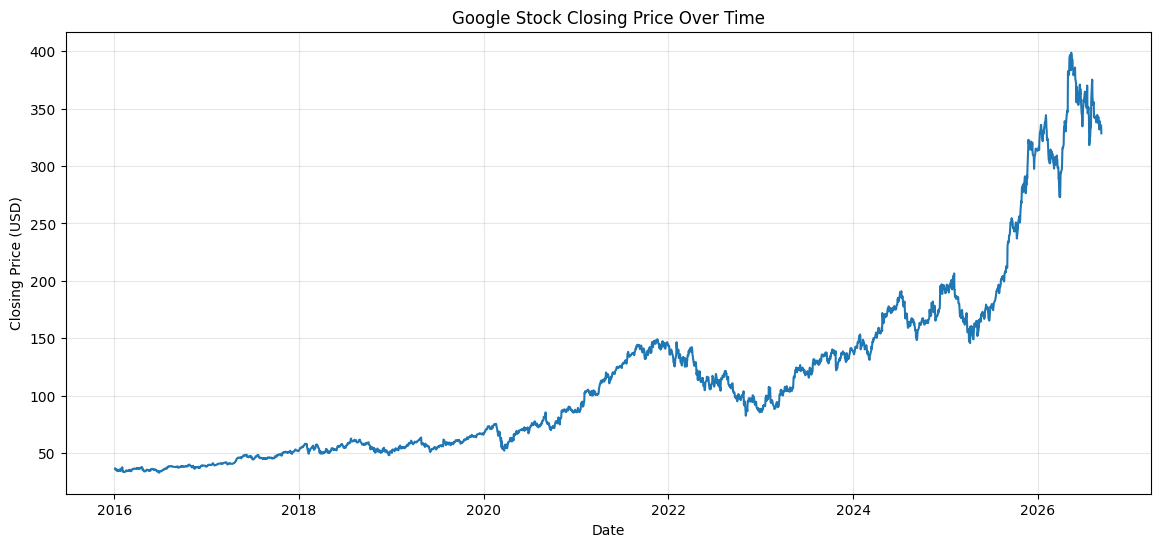

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(df['Date'], df['Close'])

plt.title('Google Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(alpha=0.3)

plt.show()

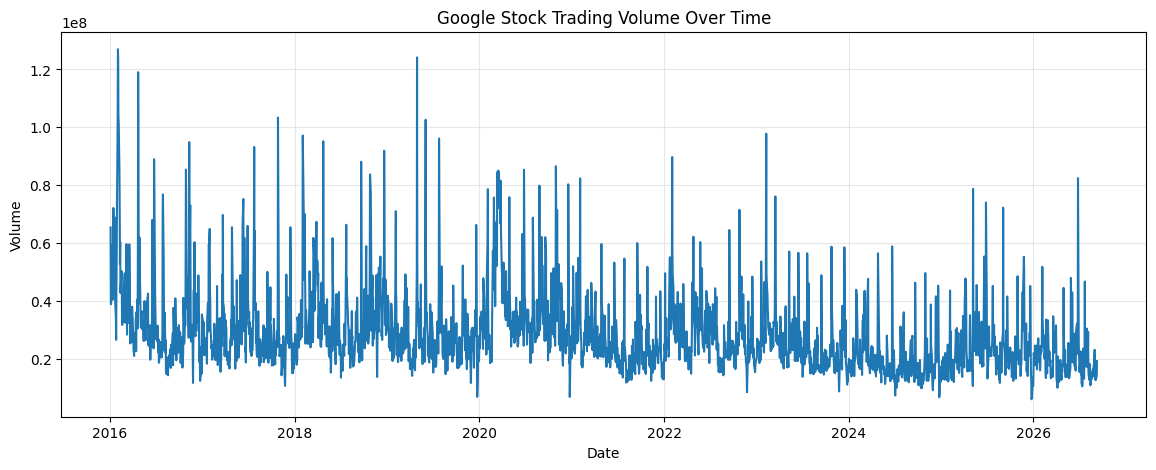

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(df['Date'], df['Volume'])

plt.title('Google Stock Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(alpha=0.3)

plt.show()

In [18]:
df['Daily_Return'] = df['Close'].pct_change()

df[['Date', 'Close', 'Daily_Return']].head()

Price,Date,Close,Daily_Return
0,2016-01-04,36.743977,NaN
1,2016-01-05,36.780628,0.000997
2,2016-01-06,36.832134,0.001400
3,2016-01-07,35.978722,-0.023170
4,2016-01-08,35.388317,-0.016410


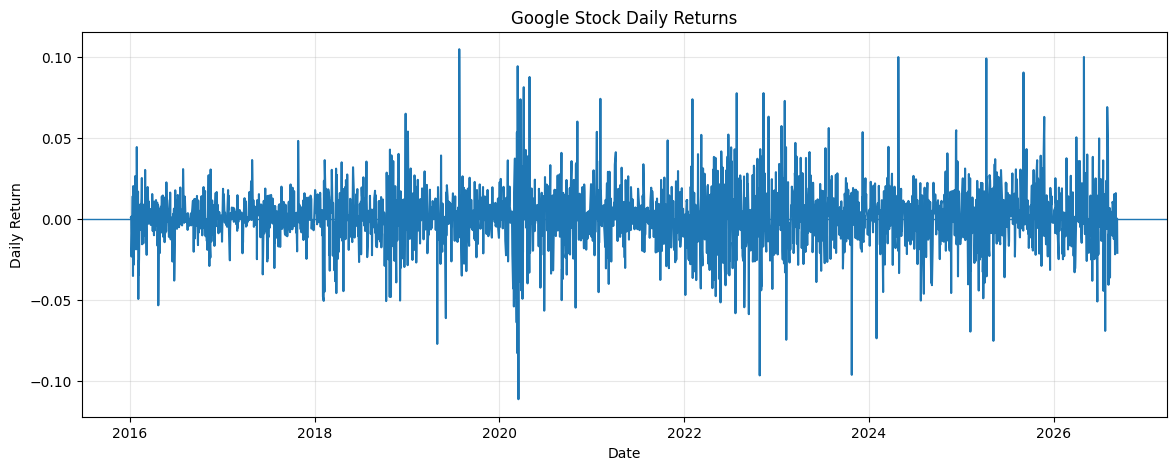

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(df['Date'], df['Daily_Return'])

plt.axhline(0, linewidth=1)

plt.title('Google Stock Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(alpha=0.3)

plt.show()

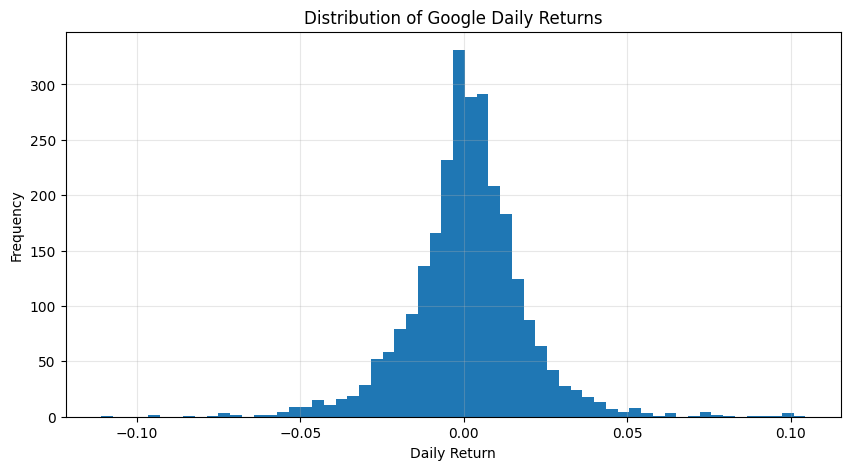

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['Daily_Return'].dropna(),
    bins=60
)

plt.title('Distribution of Google Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.show()

In [21]:
df['Daily_Return'].describe()

count    2685.000000
mean        0.000983
std         0.018263
min        -0.111008
25%        -0.007518
50%         0.001178
75%         0.010223
max         0.104485
Name: Daily_Return, dtype: float64

In [22]:
print(
    'Average daily return:',
    df['Daily_Return'].mean()
)

print(
    'Daily return volatility:',
    df['Daily_Return'].std()
)

print(
    'Maximum daily gain:',
    df['Daily_Return'].max()
)

print(
    'Maximum daily loss:',
    df['Daily_Return'].min()
)

Average daily return: 0.0009826864019754553
Daily return volatility: 0.01826334139323668
Maximum daily gain: 0.10448544741716725
Maximum daily loss: -0.1110082312322096


In [23]:
features_for_corr = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume'
]

correlation_matrix = df[features_for_corr].corr()

correlation_matrix

Price,Open,High,Low,Close,Volume
Price,,,,,
Open,1.000000,0.999844,0.999830,0.999648,-0.326010
High,0.999844,1.000000,0.999819,0.999852,-0.323085
Low,0.999830,0.999819,1.000000,0.999855,-0.330683
Close,0.999648,0.999852,0.999855,1.000000,-0.327338
Volume,-0.326010,-0.323085,-0.330683,-0.327338,1.000000


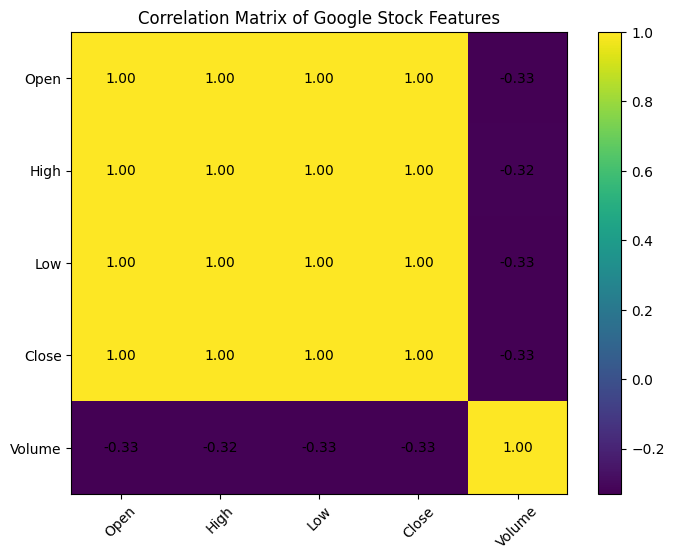

In [24]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(features_for_corr)),
    features_for_corr,
    rotation=45
)

plt.yticks(
    range(len(features_for_corr)),
    features_for_corr
)

for i in range(len(features_for_corr)):
    for j in range(len(features_for_corr)):
        plt.text(
            j,
            i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix of Google Stock Features')

plt.show()

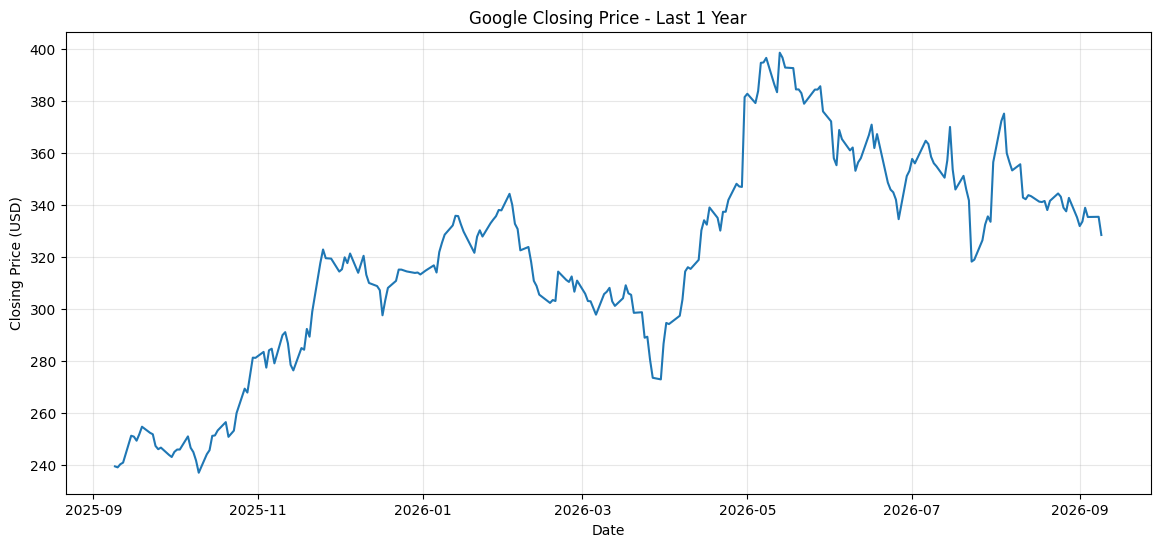

In [25]:
recent_data = df[
    df['Date'] >= df['Date'].max() - pd.DateOffset(years=1)
]

plt.figure(figsize=(14, 6))

plt.plot(
    recent_data['Date'],
    recent_data['Close']
)

plt.title('Google Closing Price - Last 1 Year')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(alpha=0.3)

plt.show()

### EDA Summary

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:12px 14px; border-radius:5px;">
<p style="margin:5px 0 9px 0;">GOOG shows a strong long-term upward price trend, so the raw price level is clearly non-stationary. Open, High, Low, and Close are almost perfectly correlated, which is expected because they describe the same asset on the same trading day.</p>
<p style="margin:5px 0 9px 0;">Daily returns are centered close to zero and contain occasional large moves. This makes return forecasting a useful alternative to predicting the raw price level directly.</p>
<p style="margin:5px 0 9px 0;">The EDA does not prove that the series is predictable; it simply gives the context needed for the sequence-model experiments that follow.</p>
</div>

## Feature Engineering

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Three simple moving averages are added with 5, 9, and 17-day windows.</li>
<li style="margin:4px 0;">Bollinger Bands are built with a 20-day rolling window, and band width is later normalized by the middle band.</li>
<li style="margin:4px 0;">These features describe short-term trend and volatility without using future observations.</li>
</ul>
</div>

In [26]:
df_fe = df.copy()

df_fe.head()

Price,Date,Open,High,Low,Close,Volume,Daily_Return
0,2016-01-04,36.801435,36.853935,36.219842,36.743977,65456000,NaN
1,2016-01-05,36.972309,37.247206,36.585474,36.780628,39014000,0.000997
2,2016-01-06,36.157524,37.008465,36.104030,36.832134,38940000,0.001400
3,2016-01-07,36.172882,36.578540,35.615660,35.978722,59274000,-0.023170
4,2016-01-08,36.229350,36.317516,35.315509,35.388317,49018000,-0.016410


In [27]:
df_fe['SMA_5'] = df_fe['Close'].rolling(window=5).mean()
df_fe['SMA_9'] = df_fe['Close'].rolling(window=9).mean()
df_fe['SMA_17'] = df_fe['Close'].rolling(window=17).mean()

df_fe[
    ['Date', 'Close', 'SMA_5', 'SMA_9', 'SMA_17']
].head(20)

Price,Date,Close,SMA_5,SMA_9,SMA_17
0,2016-01-04,36.743977,NaN,NaN,NaN
1,2016-01-05,36.780628,NaN,NaN,NaN
2,2016-01-06,36.832134,NaN,NaN,NaN
3,2016-01-07,35.978722,NaN,NaN,NaN
4,2016-01-08,35.388317,36.344756,NaN,NaN
5,2016-01-11,35.465580,36.089076,NaN,NaN
6,2016-01-12,35.962872,35.925525,NaN,NaN
7,2016-01-13,34.699337,35.498965,NaN,NaN
8,2016-01-14,35.400700,35.383361,35.916918,NaN
9,2016-01-15,34.396713,35.185040,35.656111,NaN


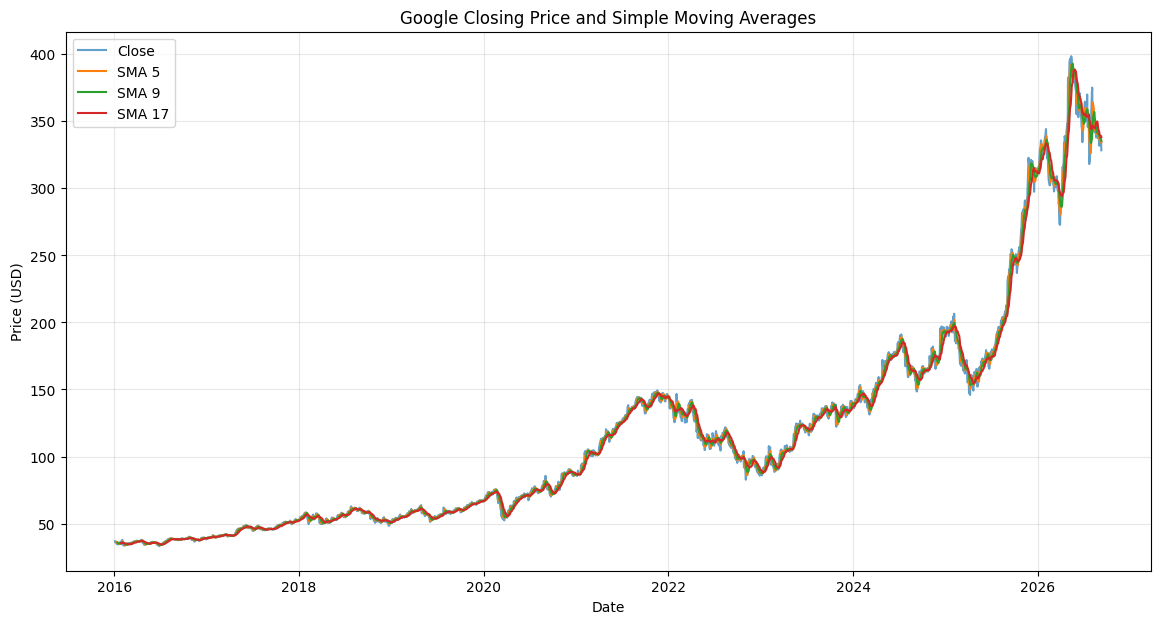

In [28]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_fe['Date'],
    df_fe['Close'],
    label='Close',
    alpha=0.7
)

plt.plot(
    df_fe['Date'],
    df_fe['SMA_5'],
    label='SMA 5'
)

plt.plot(
    df_fe['Date'],
    df_fe['SMA_9'],
    label='SMA 9'
)

plt.plot(
    df_fe['Date'],
    df_fe['SMA_17'],
    label='SMA 17'
)

plt.title('Google Closing Price and Simple Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

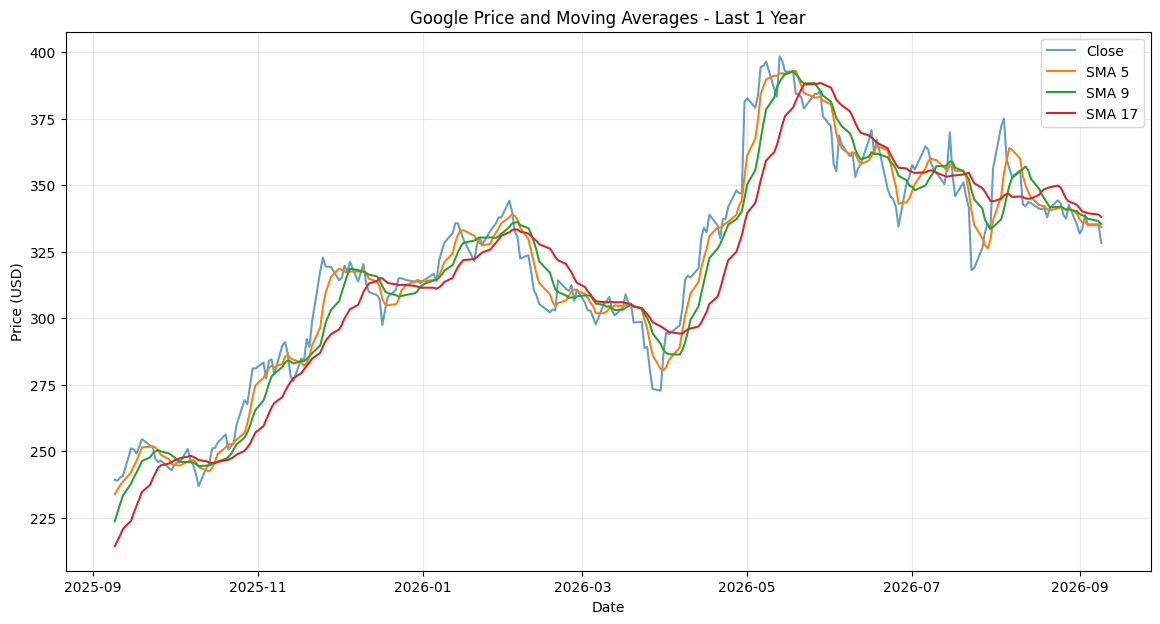

In [29]:
recent_fe = df_fe[
    df_fe['Date'] >= df_fe['Date'].max() - pd.DateOffset(years=1)
]

plt.figure(figsize=(14, 7))

plt.plot(
    recent_fe['Date'],
    recent_fe['Close'],
    label='Close',
    alpha=0.7
)

plt.plot(
    recent_fe['Date'],
    recent_fe['SMA_5'],
    label='SMA 5'
)

plt.plot(
    recent_fe['Date'],
    recent_fe['SMA_9'],
    label='SMA 9'
)

plt.plot(
    recent_fe['Date'],
    recent_fe['SMA_17'],
    label='SMA 17'
)

plt.title('Google Price and Moving Averages - Last 1 Year')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [30]:
BB_WINDOW = 20

df_fe['BB_Middle'] = (
    df_fe['Close']
    .rolling(window=BB_WINDOW)
    .mean()
)

rolling_std = (
    df_fe['Close']
    .rolling(window=BB_WINDOW)
    .std()
)

df_fe['BB_Upper'] = (
    df_fe['BB_Middle'] + 2 * rolling_std
)

df_fe['BB_Lower'] = (
    df_fe['BB_Middle'] - 2 * rolling_std
)

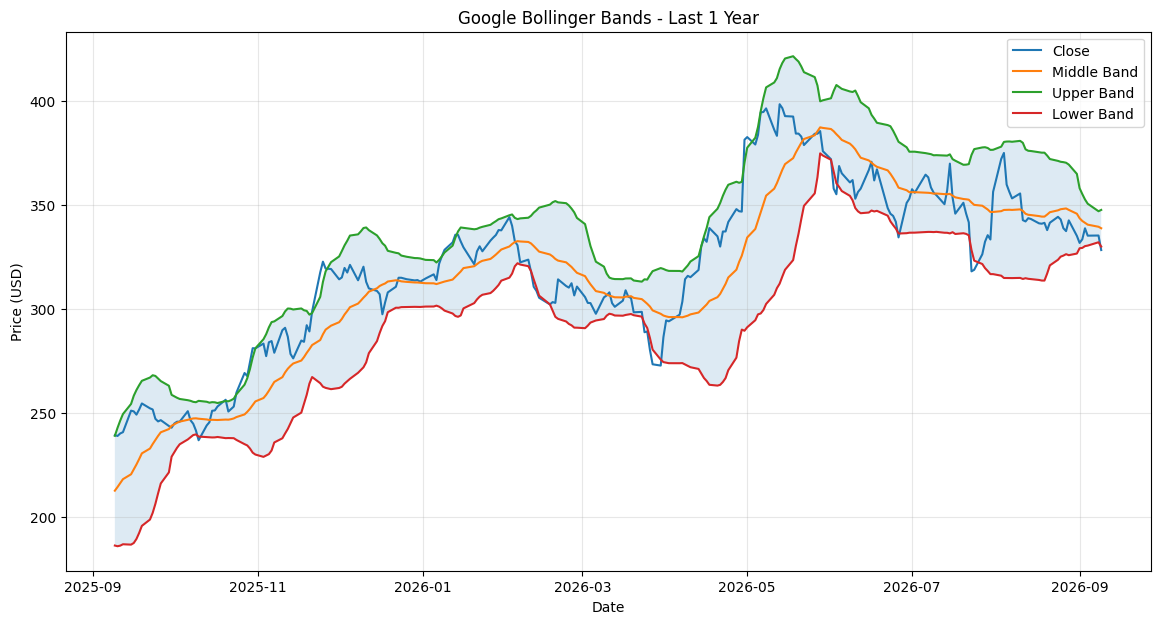

In [31]:
recent_bb = df_fe[
    df_fe['Date'] >= df_fe['Date'].max() - pd.DateOffset(years=1)
]

plt.figure(figsize=(14, 7))

plt.plot(
    recent_bb['Date'],
    recent_bb['Close'],
    label='Close'
)

plt.plot(
    recent_bb['Date'],
    recent_bb['BB_Middle'],
    label='Middle Band'
)

plt.plot(
    recent_bb['Date'],
    recent_bb['BB_Upper'],
    label='Upper Band'
)

plt.plot(
    recent_bb['Date'],
    recent_bb['BB_Lower'],
    label='Lower Band'
)

plt.fill_between(
    recent_bb['Date'],
    recent_bb['BB_Lower'],
    recent_bb['BB_Upper'],
    alpha=0.15
)

plt.title('Google Bollinger Bands - Last 1 Year')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [32]:
df_fe['BB_Width'] = (
    df_fe['BB_Upper'] - df_fe['BB_Lower']
)

In [33]:
df_fe.isnull().sum()

Price
Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
Daily_Return     1
SMA_5            4
SMA_9            8
SMA_17          16
BB_Middle       19
BB_Upper        19
BB_Lower        19
BB_Width        19
dtype: int64

In [34]:
df_fe = (
    df_fe
    .dropna()
    .reset_index(drop=True)
)

print("Final feature-engineered shape:", df_fe.shape)

print("\nMissing values:")
print(df_fe.isnull().sum())

Final feature-engineered shape: (2667, 14)

Missing values:
Price
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Daily_Return    0
SMA_5           0
SMA_9           0
SMA_17          0
BB_Middle       0
BB_Upper        0
BB_Lower        0
BB_Width        0
dtype: int64


In [35]:
df_fe.head()

Price,Date,Open,High,Low,Close,Volume,Daily_Return,SMA_5,SMA_9,SMA_17,BB_Middle,BB_Upper,BB_Lower,BB_Width
0,2016-02-01,37.170927,37.537458,36.814803,37.247204,102784000,0.012181,36.047965,35.667173,35.473944,35.670690,37.419172,33.922207,3.496965
1,2016-02-02,38.856956,39.122938,37.873768,37.873768,126962000,0.016822,36.559222,36.031500,35.585418,35.727179,37.682439,33.771920,3.910520
2,2016-02-03,38.149660,38.361649,35.686986,36.006458,123420000,-0.049304,36.826292,36.143549,35.621779,35.688471,37.585711,33.791231,3.794480
3,2016-02-04,35.801406,36.008940,34.763734,35.068352,103374000,-0.026054,36.598947,36.048670,35.598413,35.600282,37.436683,33.763880,3.672802
4,2016-02-05,34.863283,34.869227,33.688410,33.857807,102114000,-0.034520,36.010718,35.894023,35.474585,35.494236,37.477686,33.510786,3.966899


In [36]:
engineered_features = [
    'Close',
    'Volume',
    'Daily_Return',
    'SMA_5',
    'SMA_9',
    'SMA_17',
    'BB_Width'
]

df_fe[engineered_features].corr()

Price,Close,Volume,Daily_Return,SMA_5,SMA_9,SMA_17,BB_Width
Price,,,,,,,
Close,1.000000,-0.321421,0.024771,0.999310,0.998569,0.997182,0.836532
Volume,-0.321421,1.000000,-0.081874,-0.319678,-0.318227,-0.316180,-0.193839
Daily_Return,0.024771,-0.081874,1.000000,0.002639,0.000889,-0.000083,0.013738
SMA_5,0.999310,-0.319678,0.002639,1.000000,0.999653,0.998459,0.834986
SMA_9,0.998569,-0.318227,0.000889,0.999653,1.000000,0.999317,0.832012
SMA_17,0.997182,-0.316180,-0.000083,0.998459,0.999317,1.000000,0.824492
BB_Width,0.836532,-0.193839,0.013738,0.834986,0.832012,0.824492,1.000000


In [37]:
df_fe['BB_Width_Pct'] = (
    (df_fe['BB_Upper'] - df_fe['BB_Lower'])
    / df_fe['BB_Middle']
)

In [38]:
df_fe[
    [
        'Close',
        'Daily_Return',
        'Volume',
        'BB_Width',
        'BB_Width_Pct'
    ]
].corr()

Price,Close,Daily_Return,Volume,BB_Width,BB_Width_Pct
Price,,,,,
Close,1.000000,0.024771,-0.321421,0.836532,0.272059
Daily_Return,0.024771,1.000000,-0.081874,0.013738,0.005103
Volume,-0.321421,-0.081874,1.000000,-0.193839,0.115229
BB_Width,0.836532,0.013738,-0.193839,1.000000,0.653307
BB_Width_Pct,0.272059,0.005103,0.115229,0.653307,1.000000


## Data Preparation for RNN and LSTM

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The dataset is split in chronological order into training, validation, and test periods.</li>
<li style="margin:4px 0;">Scalers are fitted on the training part only, then applied to later periods.</li>
<li style="margin:4px 0;">A fixed lookback window turns the time series into supervised sequences for next-day forecasting.</li>
</ul>
</div>

In [39]:
FEATURE_COLUMNS = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'SMA_5',
    'SMA_9',
    'SMA_17',
    'Daily_Return',
    'BB_Width_Pct'
]

TARGET_COLUMN = 'Close'

In [40]:
model_df = df_fe[
    ['Date'] + FEATURE_COLUMNS
].copy()

print("Model dataset shape:", model_df.shape)

model_df.head()

Model dataset shape: (2667, 11)


Price,Date,Open,High,Low,Close,Volume,SMA_5,SMA_9,SMA_17,Daily_Return,BB_Width_Pct
0,2016-02-01,37.170927,37.537458,36.814803,37.247204,102784000,36.047965,35.667173,35.473944,0.012181,0.098035
1,2016-02-02,38.856956,39.122938,37.873768,37.873768,126962000,36.559222,36.031500,35.585418,0.016822,0.109455
2,2016-02-03,38.149660,38.361649,35.686986,36.006458,123420000,36.826292,36.143549,35.621779,-0.049304,0.106322
3,2016-02-04,35.801406,36.008940,34.763734,35.068352,103374000,36.598947,36.048670,35.598413,-0.026054,0.103168
4,2016-02-05,34.863283,34.869227,33.688410,33.857807,102114000,36.010718,35.894023,35.474585,-0.034520,0.111762


In [41]:
print(model_df.isnull().sum())

Price
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
SMA_5           0
SMA_9           0
SMA_17          0
Daily_Return    0
BB_Width_Pct    0
dtype: int64


In [42]:
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

n = len(model_df)

train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

print("Total samples:", n)

print("Train rows:", train_end)
print("Validation rows:", val_end - train_end)
print("Test rows:", n - val_end)

Total samples: 2667
Train rows: 2133
Validation rows: 267
Test rows: 267


In [43]:
print(
    "Train period:",
    model_df.iloc[0]['Date'],
    "to",
    model_df.iloc[train_end - 1]['Date']
)

print(
    "Validation period:",
    model_df.iloc[train_end]['Date'],
    "to",
    model_df.iloc[val_end - 1]['Date']
)

print(
    "Test period:",
    model_df.iloc[val_end]['Date'],
    "to",
    model_df.iloc[-1]['Date']
)

Train period: 2016-02-01 00:00:00 to 2024-07-23 00:00:00
Validation period: 2024-07-24 00:00:00 to 2025-08-15 00:00:00
Test period: 2025-08-18 00:00:00 to 2026-09-09 00:00:00


In [44]:
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

In [45]:
train_features = model_df.iloc[:train_end][FEATURE_COLUMNS]
train_target = model_df.iloc[:train_end][[TARGET_COLUMN]]

feature_scaler.fit(train_features)
target_scaler.fit(train_target)

MinMaxScaler()

In [46]:
features_scaled = feature_scaler.transform(
    model_df[FEATURE_COLUMNS]
)

target_scaled = target_scaler.transform(
    model_df[[TARGET_COLUMN]]
)

In [47]:
print("Scaled features shape:", features_scaled.shape)
print("Scaled target shape:", target_scaled.shape)

print("Feature range:",
      features_scaled.min(),
      features_scaled.max())

print("Target range:",
      target_scaled.min(),
      target_scaled.max())

Scaled features shape: (2667, 10)
Scaled target shape: (2667, 1)
Feature range: -0.006646893173145818 2.3465315026350533
Target range: 0.0 2.31336187027339


### Sequence Creation

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Each input contains the previous 10 trading days.</li>
<li style="margin:3px 0;">The target is the closing price of the following trading day.</li>
<li style="margin:3px 0;">Samples remain in chronological order throughout the split.</li>
</ul>
</div>

In [48]:
LOOKBACK = 10

In [49]:
def create_sequences(
    features,
    target,
    dates,
    lookback,
    train_end,
    val_end
):
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    train_dates = []
    val_dates = []
    test_dates = []

    for i in range(lookback, len(features)):

        X = features[i - lookback:i]

        y = target[i]

        if i < train_end:
            X_train.append(X)
            y_train.append(y)
            train_dates.append(dates.iloc[i])

        elif i < val_end:
            X_val.append(X)
            y_val.append(y)
            val_dates.append(dates.iloc[i])

        else:
            X_test.append(X)
            y_test.append(y)
            test_dates.append(dates.iloc[i])

    return (
        np.array(X_train, dtype=np.float32),
        np.array(y_train, dtype=np.float32),

        np.array(X_val, dtype=np.float32),
        np.array(y_val, dtype=np.float32),

        np.array(X_test, dtype=np.float32),
        np.array(y_test, dtype=np.float32),

        np.array(train_dates),
        np.array(val_dates),
        np.array(test_dates)
    )

In [50]:
(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    train_dates,
    val_dates,
    test_dates
) = create_sequences(
    features_scaled,
    target_scaled,
    model_df['Date'],
    LOOKBACK,
    train_end,
    val_end
)

In [51]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2123, 10, 10)
y_train: (2123, 1)

X_val: (267, 10, 10)
y_val: (267, 1)

X_test: (267, 10, 10)
y_test: (267, 1)


## PyTorch Data Preparation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The NumPy sequences are converted to PyTorch tensors.</li>
<li style="margin:4px 0;">TensorDataset and DataLoader are used for train, validation, and test data.</li>
<li style="margin:4px 0;">Shuffling is disabled because the temporal order matters.</li>
</ul>
</div>

In [52]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [53]:
print("X_train tensor:", X_train_tensor.shape)
print("y_train tensor:", y_train_tensor.shape)

print("\nX_val tensor:", X_val_tensor.shape)
print("y_val tensor:", y_val_tensor.shape)

print("\nX_test tensor:", X_test_tensor.shape)
print("y_test tensor:", y_test_tensor.shape)

print("\nData type:", X_train_tensor.dtype)

X_train tensor: torch.Size([2123, 10, 10])
y_train tensor: torch.Size([2123, 1])

X_val tensor: torch.Size([267, 10, 10])
y_val tensor: torch.Size([267, 1])

X_test tensor: torch.Size([267, 10, 10])
y_test tensor: torch.Size([267, 1])

Data type: torch.float32


In [54]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [55]:
print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 2123
Validation dataset size: 267
Test dataset size: 267


In [56]:
BATCH_SIZE = 32

In [57]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [58]:
batch_X, batch_y = next(iter(train_loader))

print("Batch X shape:", batch_X.shape)
print("Batch y shape:", batch_y.shape)

Batch X shape: torch.Size([32, 10, 10])
Batch y shape: torch.Size([32, 1])


In [59]:
INPUT_SIZE = X_train.shape[2]

print("Input size:", INPUT_SIZE)

Input size: 10


## Simple RNN Model

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The first recurrent model is a one-layer Simple RNN with 64 hidden units.</li>
<li style="margin:4px 0;">The last hidden state is passed to a linear layer for the next-day prediction.</li>
<li style="margin:4px 0;">This gives a straightforward reference point before testing LSTM.</li>
</ul>
</div>

In [60]:
HIDDEN_SIZE = 64
NUM_LAYERS = 1
LEARNING_RATE = 0.001
EPOCHS = 100
PATIENCE = 15

In [61]:
class SimpleRNN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=1
    ):
        super(SimpleRNN, self).__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, hidden = self.rnn(x)

        last_hidden = hidden[-1]

        prediction = self.fc(last_hidden)

        return prediction

In [62]:
rnn_model = SimpleRNN(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(rnn_model)

SimpleRNN(
  (rnn): RNN(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### Model Output Check

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">A sample batch is passed through the network before training.</li>
<li style="margin:3px 0;">The check confirms that one prediction is produced for each input sequence.</li>
</ul>
</div>

In [63]:
sample_X, sample_y = next(iter(train_loader))

sample_X = sample_X.to(device)

with torch.no_grad():
    sample_prediction = rnn_model(sample_X)

print("Input batch shape:", sample_X.shape)
print("Prediction shape:", sample_prediction.shape)
print("Target shape:", sample_y.shape)

Input batch shape: torch.Size([32, 10, 10])
Prediction shape: torch.Size([32, 1])
Target shape: torch.Size([32, 1])


## Loss Function and Optimizer

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Mean Squared Error is used for the regression loss.</li>
<li style="margin:4px 0;">Adam is used as the optimizer with the learning rate defined in the shared training settings.</li>
</ul>
</div>

In [64]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    rnn_model.parameters(),
    lr=LEARNING_RATE
)

## Simple RNN Training

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Training loss and validation loss are tracked after every epoch.</li>
<li style="margin:4px 0;">Gradient clipping is applied to keep recurrent training stable.</li>
<li style="margin:4px 0;">Early stopping keeps the weights from the best validation epoch rather than the final epoch.</li>
</ul>
</div>

In [65]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=100,
    patience=15
):

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):

        model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            running_train_loss += (
                loss.item() * X_batch.size(0)
            )

        train_loss = (
            running_train_loss /
            len(train_loader.dataset)
        )

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                predictions = model(X_batch)

                loss = criterion(
                    predictions,
                    y_batch
                )

                running_val_loss += (
                    loss.item() * X_batch.size(0)
                )

        val_loss = (
            running_val_loss /
            len(val_loader.dataset)
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:
            patience_counter += 1

        if epoch == 0 or (epoch + 1) % 10 == 0:

            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f}"
            )

        if patience_counter >= patience:

            print(
                f"Early stopping at epoch {epoch + 1}"
            )

            break

    model.load_state_dict(
        best_model_state
    )

    return model, train_losses, val_losses

In [66]:
rnn_model, rnn_train_losses, rnn_val_losses = train_model(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch 1/100 | Train Loss: 0.001685 | Val Loss: 0.002635
Epoch 10/100 | Train Loss: 0.000191 | Val Loss: 0.000746
Epoch 20/100 | Train Loss: 0.000139 | Val Loss: 0.000815
Epoch 30/100 | Train Loss: 0.000329 | Val Loss: 0.000668
Epoch 40/100 | Train Loss: 0.000280 | Val Loss: 0.000683
Early stopping at epoch 40


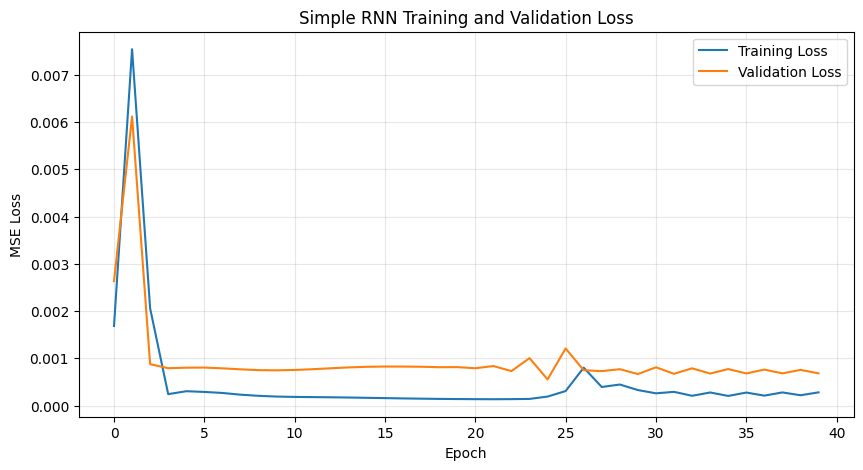

In [67]:
plt.figure(figsize=(10, 5))

plt.plot(
    rnn_train_losses,
    label='Training Loss'
)

plt.plot(
    rnn_val_losses,
    label='Validation Loss'
)

plt.title('Simple RNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [68]:
print(
    "Best Validation Loss:",
    min(rnn_val_losses)
)

Best Validation Loss: 0.0005544547182560135


## Simple RNN Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The saved best RNN is evaluated on the chronological test period.</li>
<li style="margin:4px 0;">Predictions are inverse-transformed back to US dollars.</li>
<li style="margin:4px 0;">The test set is not used during model fitting.</li>
</ul>
</div>

In [69]:
rnn_model.eval()

rnn_predictions_scaled = []
rnn_actual_scaled = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        predictions = rnn_model(X_batch)

        rnn_predictions_scaled.append(
            predictions.cpu().numpy()
        )

        rnn_actual_scaled.append(
            y_batch.numpy()
        )

In [70]:
rnn_predictions_scaled = np.vstack(
    rnn_predictions_scaled
)

rnn_actual_scaled = np.vstack(
    rnn_actual_scaled
)

print(
    "Prediction shape:",
    rnn_predictions_scaled.shape
)

print(
    "Actual shape:",
    rnn_actual_scaled.shape
)

Prediction shape: (267, 1)
Actual shape: (267, 1)


### Inverse Transformation

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Scaled targets and predictions are returned to the original closing-price scale.</li>
</ul>
</div>

In [71]:
rnn_predictions = target_scaler.inverse_transform(
    rnn_predictions_scaled
).ravel()

y_test_real = target_scaler.inverse_transform(
    rnn_actual_scaled
).ravel()

In [72]:
print(
    "First 5 actual prices:",
    y_test_real[:5]
)

print(
    "First 5 predicted prices:",
    rnn_predictions[:5]
)

First 5 actual prices: [203.5761  201.78244 199.49045 199.91895 205.99762]
First 5 predicted prices: [201.90807 201.92128 200.78838 198.97998 199.64966]


### Evaluation Metrics

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">MAE gives the average absolute price error.</li>
<li style="margin:3px 0;">MSE and RMSE place more weight on larger misses.</li>
</ul>
</div>

In [73]:
rnn_mae = mean_absolute_error(
    y_test_real,
    rnn_predictions
)

rnn_mse = mean_squared_error(
    y_test_real,
    rnn_predictions
)

rnn_rmse = np.sqrt(
    rnn_mse
)

print(
    f"Simple RNN MAE:  {rnn_mae:.4f}"
)

print(
    f"Simple RNN MSE:  {rnn_mse:.4f}"
)

print(
    f"Simple RNN RMSE: {rnn_rmse:.4f}"
)

Simple RNN MAE:  26.9702
Simple RNN MSE:  935.9254
Simple RNN RMSE: 30.5929


### Actual vs Predicted Prices

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Actual and predicted closing prices are plotted over the same test dates to make systematic errors easier to see.</li>
</ul>
</div>

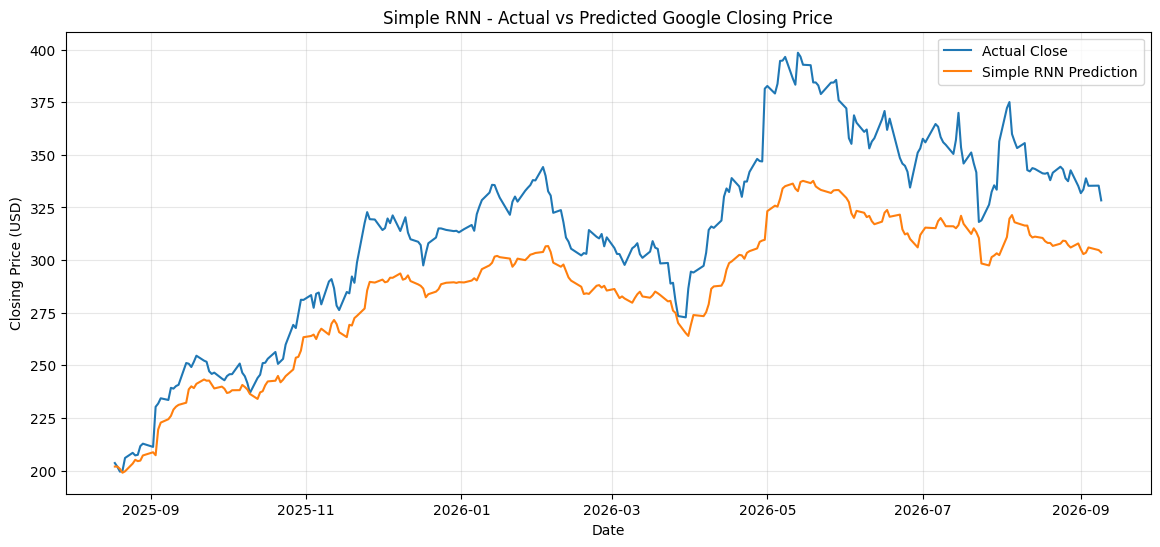

In [74]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test_real,
    label='Actual Close'
)

plt.plot(
    test_dates,
    rnn_predictions,
    label='Simple RNN Prediction'
)

plt.title(
    'Simple RNN - Actual vs Predicted Google Closing Price'
)

plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

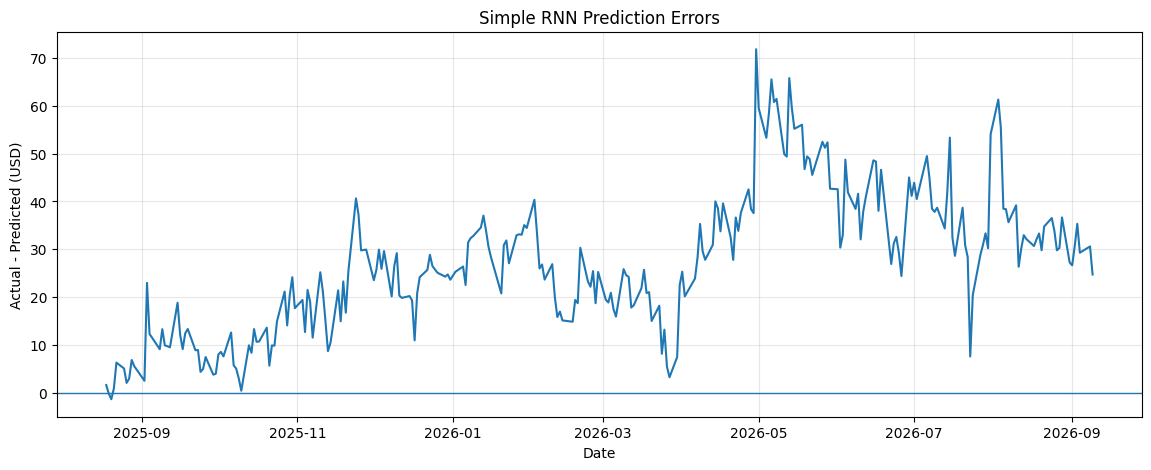

In [75]:
rnn_errors = (
    y_test_real -
    rnn_predictions
)

plt.figure(figsize=(14, 5))

plt.plot(
    test_dates,
    rnn_errors
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    'Simple RNN Prediction Errors'
)

plt.xlabel('Date')
plt.ylabel('Actual - Predicted (USD)')

plt.grid(alpha=0.3)

plt.show()

### Simple RNN Result

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:12px 14px; border-radius:5px;">
<p style="margin:5px 0 9px 0;">The direct-price RNN follows the broad shape of the series but underestimates the higher price regime in the test period.</p>
<p style="margin:5px 0 9px 0;">Its MAE is about 25.69 USD and RMSE about 29.31 USD. This is a useful warning that a model can track the trend visually and still perform poorly against a simple forecast.</p>
</div>

## LSTM Model

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The LSTM uses the same inputs, lookback window, hidden size, and split as the Simple RNN.</li>
<li style="margin:4px 0;">Keeping the setup fixed makes the architecture comparison fair.</li>
</ul>
</div>

In [76]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=1
    ):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        last_hidden = hidden[-1]

        prediction = self.fc(last_hidden)

        return prediction

### Model Initialization

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">The network uses 64 hidden units and one recurrent layer.</li>
<li style="margin:3px 0;">The final hidden state is mapped to a single next-day closing-price prediction.</li>
</ul>
</div>

In [77]:
lstm_model = LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(lstm_model)

LSTMModel(
  (lstm): LSTM(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [78]:
sample_X, sample_y = next(iter(train_loader))

sample_X = sample_X.to(device)

with torch.no_grad():
    sample_prediction = lstm_model(sample_X)

print("Input batch shape:", sample_X.shape)
print("Prediction shape:", sample_prediction.shape)
print("Target shape:", sample_y.shape)

Input batch shape: torch.Size([32, 10, 10])
Prediction shape: torch.Size([32, 1])
Target shape: torch.Size([32, 1])


## LSTM Training

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The LSTM is trained with the same MSE loss, Adam optimizer, and early-stopping routine used for the RNN.</li>
</ul>
</div>

In [79]:
lstm_criterion = nn.MSELoss()

lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=LEARNING_RATE
)

In [80]:
lstm_model, lstm_train_losses, lstm_val_losses = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=lstm_criterion,
    optimizer=lstm_optimizer,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch 1/100 | Train Loss: 0.001543 | Val Loss: 0.002206
Epoch 10/100 | Train Loss: 0.000435 | Val Loss: 0.001270
Epoch 20/100 | Train Loss: 0.000321 | Val Loss: 0.000743
Epoch 30/100 | Train Loss: 0.000295 | Val Loss: 0.000653
Epoch 40/100 | Train Loss: 0.000150 | Val Loss: 0.000674
Early stopping at epoch 44


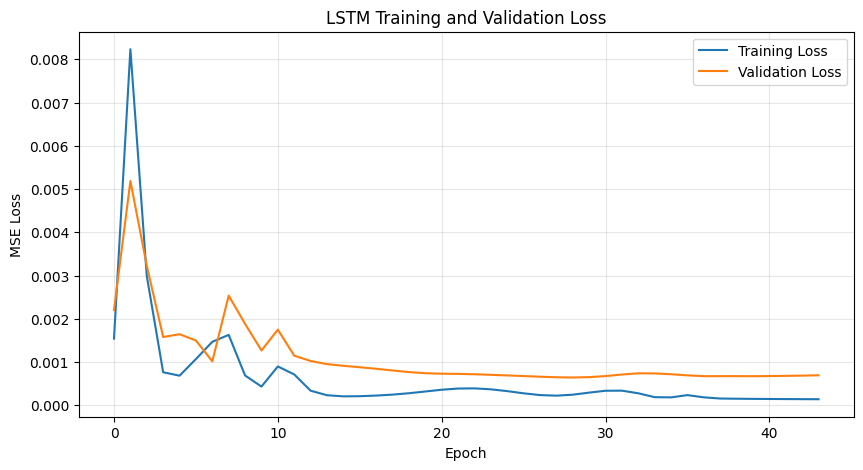

In [81]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_train_losses,
    label='Training Loss'
)

plt.plot(
    lstm_val_losses,
    label='Validation Loss'
)

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [82]:
print(
    "Best LSTM Validation Loss:",
    min(lstm_val_losses)
)

Best LSTM Validation Loss: 0.0006442990697735453


## LSTM Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The best LSTM checkpoint is evaluated on the same chronological test period.</li>
<li style="margin:4px 0;">Predictions are converted back to the original dollar scale before calculating errors.</li>
</ul>
</div>

In [83]:
lstm_model.eval()

lstm_predictions_scaled = []
lstm_actual_scaled = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        predictions = lstm_model(X_batch)

        lstm_predictions_scaled.append(
            predictions.cpu().numpy()
        )

        lstm_actual_scaled.append(
            y_batch.numpy()
        )

In [84]:
lstm_predictions_scaled = np.vstack(
    lstm_predictions_scaled
)

lstm_actual_scaled = np.vstack(
    lstm_actual_scaled
)

print(
    "Prediction shape:",
    lstm_predictions_scaled.shape
)

print(
    "Actual shape:",
    lstm_actual_scaled.shape
)

Prediction shape: (267, 1)
Actual shape: (267, 1)


In [85]:
lstm_predictions = target_scaler.inverse_transform(
    lstm_predictions_scaled
).ravel()

lstm_y_test_real = target_scaler.inverse_transform(
    lstm_actual_scaled
).ravel()

In [86]:
lstm_mae = mean_absolute_error(
    lstm_y_test_real,
    lstm_predictions
)

lstm_mse = mean_squared_error(
    lstm_y_test_real,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    lstm_mse
)

print(
    f"LSTM MAE:  {lstm_mae:.4f}"
)

print(
    f"LSTM MSE:  {lstm_mse:.4f}"
)

print(
    f"LSTM RMSE: {lstm_rmse:.4f}"
)

LSTM MAE:  18.7783
LSTM MSE:  486.2801
LSTM RMSE: 22.0518


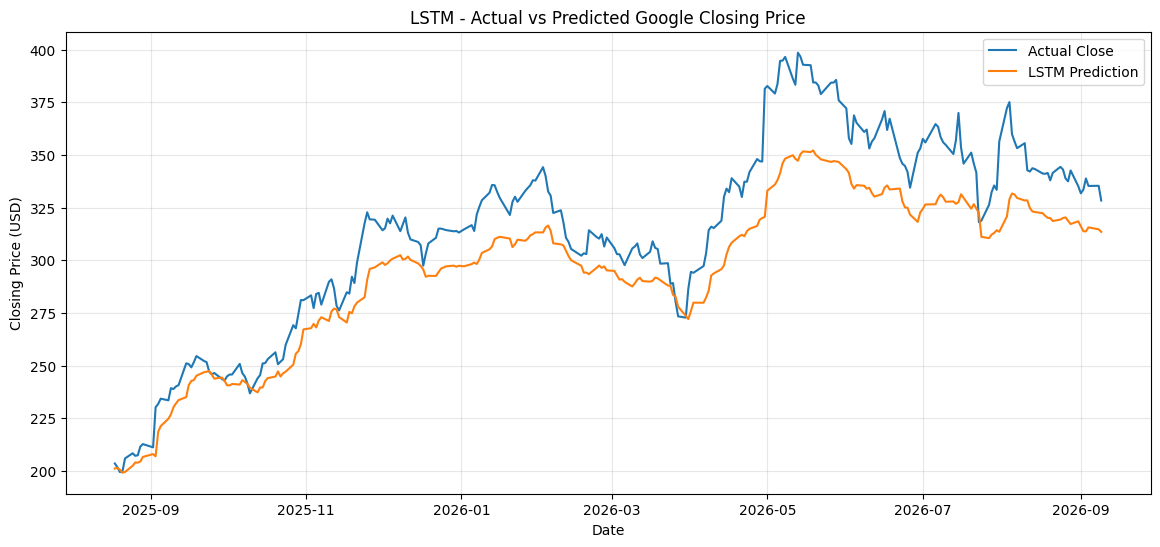

In [87]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    lstm_y_test_real,
    label='Actual Close'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='LSTM Prediction'
)

plt.title(
    'LSTM - Actual vs Predicted Google Closing Price'
)

plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

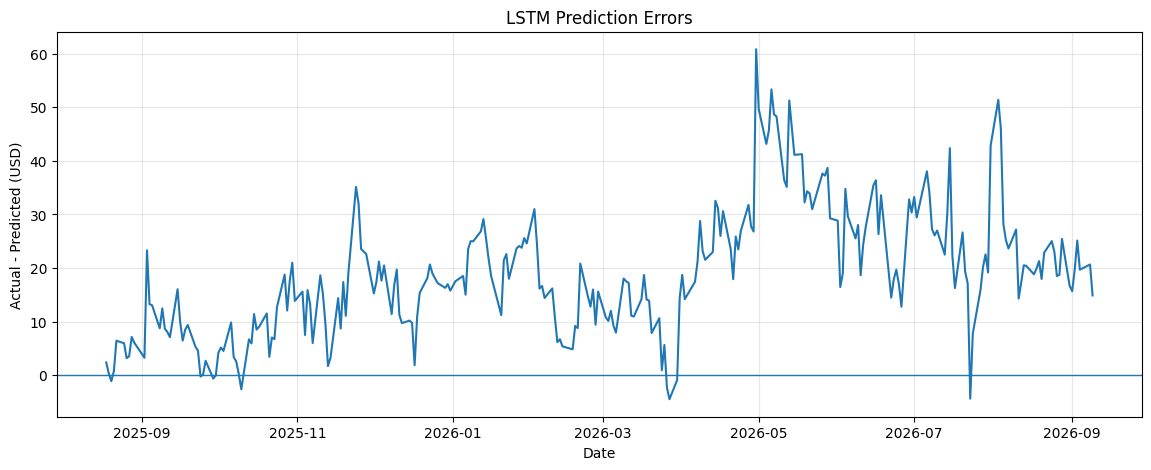

In [88]:
lstm_errors = (
    lstm_y_test_real -
    lstm_predictions
)

plt.figure(figsize=(14, 5))

plt.plot(
    test_dates,
    lstm_errors
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    'LSTM Prediction Errors'
)

plt.xlabel('Date')
plt.ylabel('Actual - Predicted (USD)')

plt.grid(alpha=0.3)

plt.show()

## Simple RNN vs LSTM

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Both recurrent models are compared on exactly the same test samples.</li>
<li style="margin:4px 0;">MAE, MSE, and RMSE are reported side by side.</li>
</ul>
</div>

In [89]:
comparison_results = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM'
    ],
    
    'MAE': [
        rnn_mae,
        lstm_mae
    ],
    
    'MSE': [
        rnn_mse,
        lstm_mse
    ],
    
    'RMSE': [
        rnn_rmse,
        lstm_rmse
    ]
})

comparison_results

,Model,MAE,MSE,RMSE
0,Simple RNN,26.970173,935.925415,30.592898
1,LSTM,18.778259,486.280121,22.051760


### Prediction Comparison

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">The RNN and LSTM predictions are plotted with the actual closing price to compare their behavior over time.</li>
</ul>
</div>

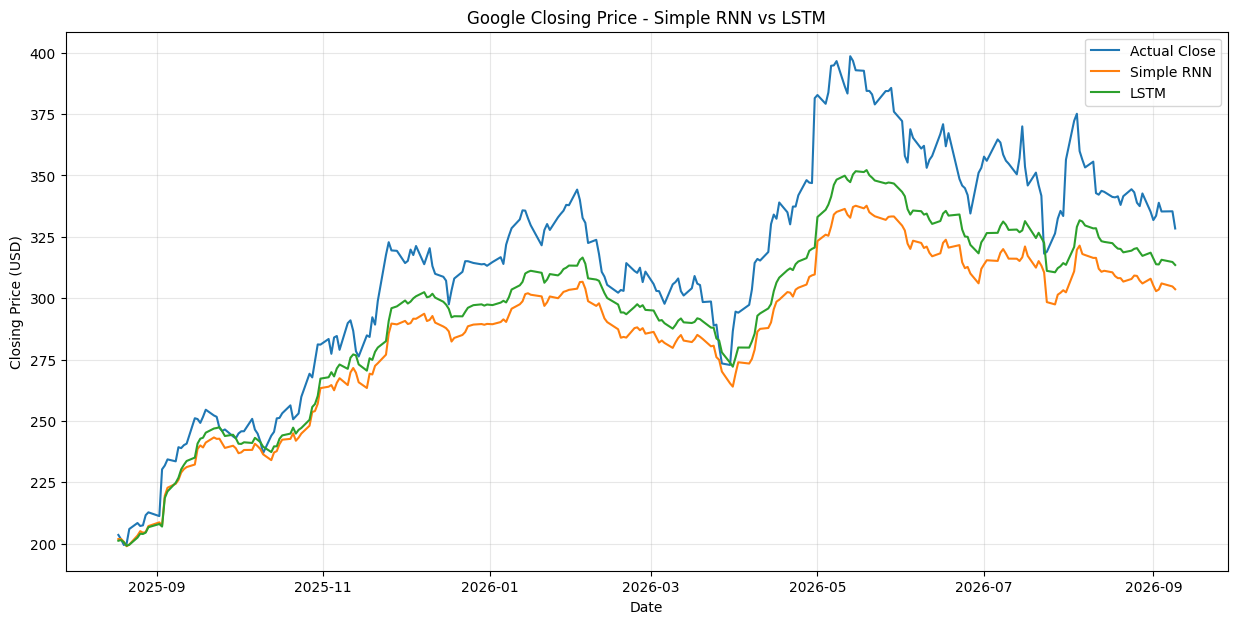

In [90]:
plt.figure(figsize=(15, 7))

plt.plot(
    test_dates,
    y_test_real,
    label='Actual Close'
)

plt.plot(
    test_dates,
    rnn_predictions,
    label='Simple RNN'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='LSTM'
)

plt.title(
    'Google Closing Price - Simple RNN vs LSTM'
)

plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Naive Forecasting Baseline

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The baseline simply uses the most recent closing price as the forecast for the next trading day.</li>
<li style="margin:4px 0;">This is intentionally simple, but it is a strong benchmark for one-step stock-price forecasting.</li>
</ul>
</div>

In [91]:
test_indices = np.arange(
    val_end,
    len(model_df)
)

naive_predictions = (
    model_df['Close']
    .iloc[test_indices - 1]
    .to_numpy()
)

print(
    "Naive predictions shape:",
    naive_predictions.shape
)

Naive predictions shape: (267,)


In [92]:
naive_mae = mean_absolute_error(
    y_test_real,
    naive_predictions
)

naive_mse = mean_squared_error(
    y_test_real,
    naive_predictions
)

naive_rmse = np.sqrt(
    naive_mse
)

print(
    f"Naive MAE:  {naive_mae:.4f}"
)

print(
    f"Naive MSE:  {naive_mse:.4f}"
)

print(
    f"Naive RMSE: {naive_rmse:.4f}"
)

Naive MAE:  4.4370
Naive MSE:  40.0886
Naive RMSE: 6.3316


In [93]:
final_results = pd.DataFrame({
    'Model': [
        'Naive Baseline',
        'Simple RNN',
        'LSTM'
    ],

    'MAE': [
        naive_mae,
        rnn_mae,
        lstm_mae
    ],

    'MSE': [
        naive_mse,
        rnn_mse,
        lstm_mse
    ],

    'RMSE': [
        naive_rmse,
        rnn_rmse,
        lstm_rmse
    ]
})

final_results

,Model,MAE,MSE,RMSE
0,Naive Baseline,4.437008,40.088640,6.331559
1,Simple RNN,26.970173,935.925415,30.592898
2,LSTM,18.778259,486.280121,22.051760


## Return-Based Forecasting

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Because the raw-price models struggle with changing price levels, the next experiment predicts the next-day return instead.</li>
<li style="margin:4px 0;">Relative features are used so the model focuses on short-term movement rather than the absolute price regime.</li>
</ul>
</div>

In [94]:
df_return = df_fe.copy()

df_return['Volume_Change'] = (
    df_return['Volume']
    .pct_change()
)

df_return['Open_Close_Pct'] = (
    (df_return['Close'] - df_return['Open'])
    / df_return['Open']
)

df_return['High_Low_Pct'] = (
    (df_return['High'] - df_return['Low'])
    / df_return['Close']
)

df_return['Close_SMA5_Pct'] = (
    (df_return['Close'] - df_return['SMA_5'])
    / df_return['SMA_5']
)

df_return['Close_SMA9_Pct'] = (
    (df_return['Close'] - df_return['SMA_9'])
    / df_return['SMA_9']
)

df_return['Close_SMA17_Pct'] = (
    (df_return['Close'] - df_return['SMA_17'])
    / df_return['SMA_17']
)

In [95]:
df_return = (
    df_return
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

print("Dataset shape:", df_return.shape)
print("\nMissing values:")
print(df_return.isnull().sum().sum())

Dataset shape: (2666, 21)

Missing values:
0


### Relative Feature Set

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Inputs include daily return, volume change, intraday range, moving-average deviations, and normalized Bollinger width.</li>
<li style="margin:3px 0;">The target is the following trading day's return.</li>
</ul>
</div>

In [96]:
RETURN_FEATURES = [
    'Daily_Return',
    'Volume_Change',
    'Open_Close_Pct',
    'High_Low_Pct',
    'Close_SMA5_Pct',
    'Close_SMA9_Pct',
    'Close_SMA17_Pct',
    'BB_Width_Pct'
]

RETURN_TARGET = 'Daily_Return'

In [97]:
return_model_df = df_return[
    ['Date', 'Close'] + RETURN_FEATURES
].copy()

print(
    "Return model shape:",
    return_model_df.shape
)

return_model_df.head()

Return model shape: (2666, 10)


Price,Date,Close,Daily_Return,Volume_Change,Open_Close_Pct,High_Low_Pct,Close_SMA5_Pct,Close_SMA9_Pct,Close_SMA17_Pct,BB_Width_Pct
0,2016-02-02,37.873768,0.016822,0.235231,-0.025303,0.032982,0.035957,0.051129,0.064306,0.109455
1,2016-02-03,36.006458,-0.049304,-0.027898,-0.056179,0.074283,-0.022262,-0.003793,0.010799,0.106322
2,2016-02-04,35.068352,-0.026054,-0.162421,-0.020476,0.035508,-0.041821,-0.027194,-0.014890,0.103168
3,2016-02-05,33.857807,-0.034520,-0.012189,-0.028841,0.034876,-0.059785,-0.056729,-0.045576,0.111762
4,2016-02-08,33.816704,-0.001214,-0.168106,0.022295,0.030714,-0.042687,-0.053476,-0.045337,0.119771


In [98]:
n_return = len(return_model_df)

return_train_end = int(
    n_return * 0.80
)

return_val_end = int(
    n_return * 0.90
)

print(
    "Train:",
    return_train_end
)

print(
    "Validation:",
    return_val_end - return_train_end
)

print(
    "Test:",
    n_return - return_val_end
)

Train: 2132
Validation: 267
Test: 267


In [99]:
return_feature_scaler = StandardScaler()
return_target_scaler = StandardScaler()

In [100]:
return_train_features = (
    return_model_df
    .iloc[:return_train_end][RETURN_FEATURES]
)

return_train_target = (
    return_model_df
    .iloc[:return_train_end][[RETURN_TARGET]]
)

return_feature_scaler.fit(
    return_train_features
)

return_target_scaler.fit(
    return_train_target
)

StandardScaler()

In [101]:
return_features_scaled = (
    return_feature_scaler.transform(
        return_model_df[RETURN_FEATURES]
    )
)

return_target_scaled = (
    return_target_scaler.transform(
        return_model_df[[RETURN_TARGET]]
    )
)

print(
    "Features shape:",
    return_features_scaled.shape
)

print(
    "Target shape:",
    return_target_scaled.shape
)

Features shape: (2666, 8)
Target shape: (2666, 1)


In [102]:
(
    X_train_return,
    y_train_return,
    X_val_return,
    y_val_return,
    X_test_return,
    y_test_return,
    train_dates_return,
    val_dates_return,
    test_dates_return
) = create_sequences(
    return_features_scaled,
    return_target_scaled,
    return_model_df['Date'],
    LOOKBACK,
    return_train_end,
    return_val_end
)

In [103]:
print(
    "X_train:",
    X_train_return.shape
)

print(
    "y_train:",
    y_train_return.shape
)

print(
    "\nX_val:",
    X_val_return.shape
)

print(
    "y_val:",
    y_val_return.shape
)

print(
    "\nX_test:",
    X_test_return.shape
)

print(
    "y_test:",
    y_test_return.shape
)

X_train: (2122, 10, 8)
y_train: (2122, 1)

X_val: (267, 10, 8)
y_val: (267, 1)

X_test: (267, 10, 8)
y_test: (267, 1)


## PyTorch Preparation for Return Forecasting

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The return-based sequences are converted to tensors and loaded without shuffling.</li>
<li style="margin:4px 0;">The same train/validation/test chronology is preserved.</li>
</ul>
</div>

In [104]:
X_train_return_tensor = torch.tensor(
    X_train_return,
    dtype=torch.float32
)

y_train_return_tensor = torch.tensor(
    y_train_return,
    dtype=torch.float32
)

X_val_return_tensor = torch.tensor(
    X_val_return,
    dtype=torch.float32
)

y_val_return_tensor = torch.tensor(
    y_val_return,
    dtype=torch.float32
)

X_test_return_tensor = torch.tensor(
    X_test_return,
    dtype=torch.float32
)

y_test_return_tensor = torch.tensor(
    y_test_return,
    dtype=torch.float32
)

In [105]:
train_return_dataset = TensorDataset(
    X_train_return_tensor,
    y_train_return_tensor
)

val_return_dataset = TensorDataset(
    X_val_return_tensor,
    y_val_return_tensor
)

test_return_dataset = TensorDataset(
    X_test_return_tensor,
    y_test_return_tensor
)

In [106]:
train_return_loader = DataLoader(
    train_return_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_return_loader = DataLoader(
    val_return_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_return_loader = DataLoader(
    test_return_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [107]:
batch_X_return, batch_y_return = next(
    iter(train_return_loader)
)

print(
    "Batch X shape:",
    batch_X_return.shape
)

print(
    "Batch y shape:",
    batch_y_return.shape
)

Batch X shape: torch.Size([32, 10, 8])
Batch y shape: torch.Size([32, 1])


In [108]:
RETURN_INPUT_SIZE = X_train_return.shape[2]

print(
    "Return model input size:",
    RETURN_INPUT_SIZE
)

Return model input size: 8


## Return-Based Simple RNN

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">A Simple RNN is trained on the relative feature set to predict the next-day return.</li>
</ul>
</div>

In [109]:
rnn_return_model = SimpleRNN(
    input_size=RETURN_INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(rnn_return_model)

SimpleRNN(
  (rnn): RNN(8, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [110]:
sample_X_return, sample_y_return = next(
    iter(train_return_loader)
)

sample_X_return = sample_X_return.to(device)

with torch.no_grad():
    sample_return_prediction = rnn_return_model(
        sample_X_return
    )

print(
    "Input batch shape:",
    sample_X_return.shape
)

print(
    "Prediction shape:",
    sample_return_prediction.shape
)

print(
    "Target shape:",
    sample_y_return.shape
)

Input batch shape: torch.Size([32, 10, 8])
Prediction shape: torch.Size([32, 1])
Target shape: torch.Size([32, 1])


### Loss and Optimizer

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">MSE and Adam are kept unchanged so the comparison with the earlier experiment is easier to interpret.</li>
</ul>
</div>

In [111]:
rnn_return_criterion = nn.MSELoss()

rnn_return_optimizer = torch.optim.Adam(
    rnn_return_model.parameters(),
    lr=LEARNING_RATE
)

### Training

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">The same maximum epoch count and early-stopping rule are used for the return-based RNN.</li>
</ul>
</div>

In [112]:
(
    rnn_return_model,
    rnn_return_train_losses,
    rnn_return_val_losses
) = train_model(
    model=rnn_return_model,
    train_loader=train_return_loader,
    val_loader=val_return_loader,
    criterion=rnn_return_criterion,
    optimizer=rnn_return_optimizer,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch 1/100 | Train Loss: 1.013691 | Val Loss: 1.176127
Epoch 10/100 | Train Loss: 0.983039 | Val Loss: 1.178865
Early stopping at epoch 19


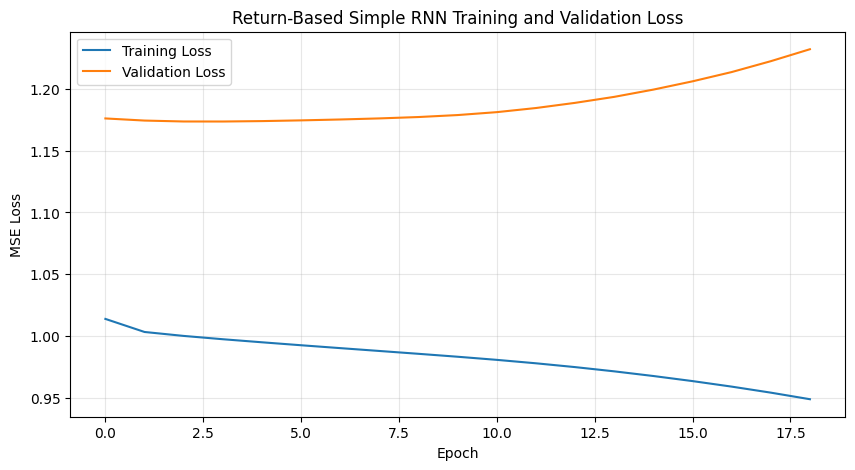

In [113]:
plt.figure(figsize=(10, 5))

plt.plot(
    rnn_return_train_losses,
    label='Training Loss'
)

plt.plot(
    rnn_return_val_losses,
    label='Validation Loss'
)

plt.title(
    'Return-Based Simple RNN Training and Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [114]:
print(
    "Best Return RNN Validation Loss:",
    min(rnn_return_val_losses)
)

Best Return RNN Validation Loss: 1.1736344422740437


## Return-Based RNN Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Predicted returns are inverse-transformed to their original scale.</li>
<li style="margin:4px 0;">Each predicted return is converted back into a next-day closing-price forecast using the previous close.</li>
</ul>
</div>

In [115]:
rnn_return_model.eval()

rnn_return_predictions_scaled = []
rnn_return_actual_scaled = []

with torch.no_grad():

    for X_batch, y_batch in test_return_loader:

        X_batch = X_batch.to(device)

        predictions = rnn_return_model(X_batch)

        rnn_return_predictions_scaled.append(
            predictions.cpu().numpy()
        )

        rnn_return_actual_scaled.append(
            y_batch.numpy()
        )

In [116]:
rnn_return_predictions_scaled = np.vstack(
    rnn_return_predictions_scaled
)

rnn_return_actual_scaled = np.vstack(
    rnn_return_actual_scaled
)

print(
    "Prediction shape:",
    rnn_return_predictions_scaled.shape
)

print(
    "Actual shape:",
    rnn_return_actual_scaled.shape
)

Prediction shape: (267, 1)
Actual shape: (267, 1)


In [117]:
rnn_predicted_returns = (
    return_target_scaler
    .inverse_transform(
        rnn_return_predictions_scaled
    )
    .ravel()
)

actual_returns = (
    return_target_scaler
    .inverse_transform(
        rnn_return_actual_scaled
    )
    .ravel()
)

In [118]:
return_test_indices = np.arange(
    return_val_end,
    len(return_model_df)
)

previous_close = (
    return_model_df['Close']
    .iloc[return_test_indices - 1]
    .to_numpy()
)

actual_close_return = (
    return_model_df['Close']
    .iloc[return_test_indices]
    .to_numpy()
)

In [119]:
rnn_return_price_predictions = (
    previous_close *
    (1 + rnn_predicted_returns)
)

In [120]:
rnn_return_mae = mean_absolute_error(
    actual_close_return,
    rnn_return_price_predictions
)

rnn_return_mse = mean_squared_error(
    actual_close_return,
    rnn_return_price_predictions
)

rnn_return_rmse = np.sqrt(
    rnn_return_mse
)

print(
    f"Return-RNN MAE:  {rnn_return_mae:.4f}"
)

print(
    f"Return-RNN MSE:  {rnn_return_mse:.4f}"
)

print(
    f"Return-RNN RMSE: {rnn_return_rmse:.4f}"
)

Return-RNN MAE:  4.5087
Return-RNN MSE:  40.7073
Return-RNN RMSE: 6.3802


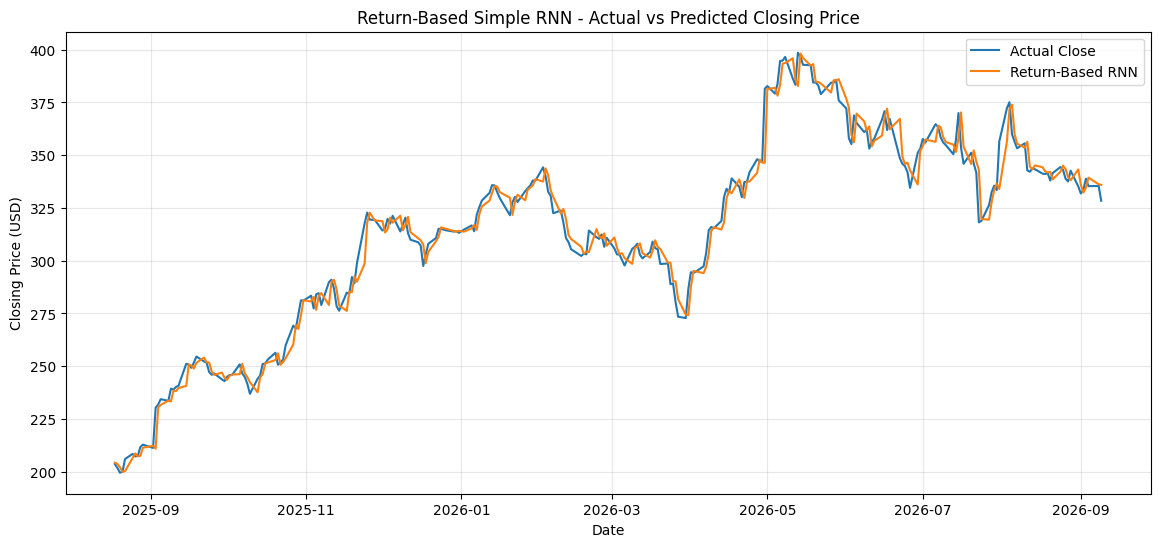

In [121]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_return,
    actual_close_return,
    label='Actual Close'
)

plt.plot(
    test_dates_return,
    rnn_return_price_predictions,
    label='Return-Based RNN'
)

plt.title(
    'Return-Based Simple RNN - Actual vs Predicted Closing Price'
)

plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [122]:
zero_return_predictions = previous_close

zero_return_mae = mean_absolute_error(
    actual_close_return,
    zero_return_predictions
)

zero_return_mse = mean_squared_error(
    actual_close_return,
    zero_return_predictions
)

zero_return_rmse = np.sqrt(
    zero_return_mse
)

print(
    f"Zero-Return Baseline MAE:  {zero_return_mae:.4f}"
)

print(
    f"Zero-Return Baseline RMSE: {zero_return_rmse:.4f}"
)

Zero-Return Baseline MAE:  4.4370
Zero-Return Baseline RMSE: 6.3316


## Return-Based LSTM

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The LSTM receives the same return-based inputs and uses the same training setup as the return-based RNN.</li>
</ul>
</div>

In [123]:
lstm_return_model = LSTMModel(
    input_size=RETURN_INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(lstm_return_model)

LSTMModel(
  (lstm): LSTM(8, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [124]:
sample_X_return, sample_y_return = next(
    iter(train_return_loader)
)

sample_X_return = sample_X_return.to(device)

with torch.no_grad():
    sample_return_prediction = lstm_return_model(
        sample_X_return
    )

print("Input batch shape:", sample_X_return.shape)
print("Prediction shape:", sample_return_prediction.shape)
print("Target shape:", sample_y_return.shape)

Input batch shape: torch.Size([32, 10, 8])
Prediction shape: torch.Size([32, 1])
Target shape: torch.Size([32, 1])


### Loss and Optimizer

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">MSE loss and Adam are used with the same learning rate as the RNN.</li>
</ul>
</div>

In [125]:
lstm_return_criterion = nn.MSELoss()

lstm_return_optimizer = torch.optim.Adam(
    lstm_return_model.parameters(),
    lr=LEARNING_RATE
)

### Training

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Early stopping is based on validation loss, with the best checkpoint restored before evaluation.</li>
</ul>
</div>

In [126]:
(
    lstm_return_model,
    lstm_return_train_losses,
    lstm_return_val_losses
) = train_model(
    model=lstm_return_model,
    train_loader=train_return_loader,
    val_loader=val_return_loader,
    criterion=lstm_return_criterion,
    optimizer=lstm_return_optimizer,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch 1/100 | Train Loss: 0.997683 | Val Loss: 1.182548
Epoch 10/100 | Train Loss: 0.941328 | Val Loss: 1.175001
Epoch 20/100 | Train Loss: 0.803914 | Val Loss: 1.431803
Early stopping at epoch 22


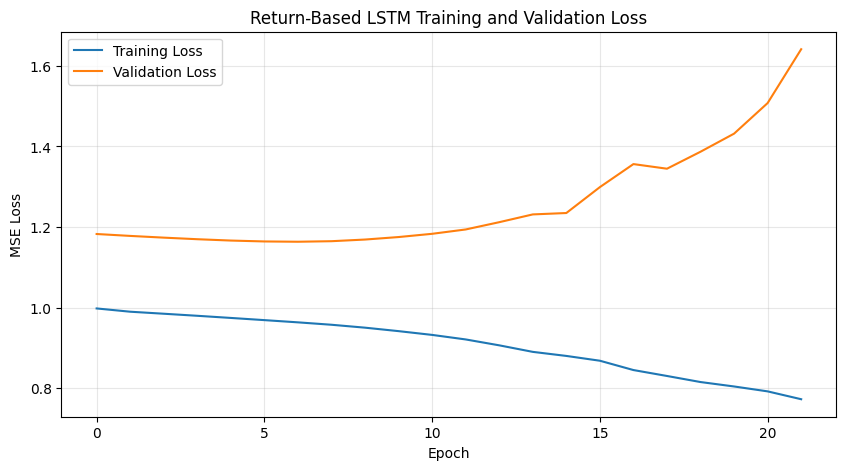

In [127]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_return_train_losses,
    label='Training Loss'
)

plt.plot(
    lstm_return_val_losses,
    label='Validation Loss'
)

plt.title(
    'Return-Based LSTM Training and Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [128]:
print(
    "Best Return LSTM Validation Loss:",
    min(lstm_return_val_losses)
)

Best Return LSTM Validation Loss: 1.1633484754223056


## Return-Based LSTM Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Predicted returns are transformed back to their original scale and reconstructed as next-day closing prices.</li>
</ul>
</div>

In [129]:
lstm_return_model.eval()

lstm_return_predictions_scaled = []
lstm_return_actual_scaled = []

with torch.no_grad():

    for X_batch, y_batch in test_return_loader:

        X_batch = X_batch.to(device)

        predictions = lstm_return_model(X_batch)

        lstm_return_predictions_scaled.append(
            predictions.cpu().numpy()
        )

        lstm_return_actual_scaled.append(
            y_batch.numpy()
        )

In [130]:
lstm_return_predictions_scaled = np.vstack(
    lstm_return_predictions_scaled
)

lstm_return_actual_scaled = np.vstack(
    lstm_return_actual_scaled
)

print(
    "Prediction shape:",
    lstm_return_predictions_scaled.shape
)

print(
    "Actual shape:",
    lstm_return_actual_scaled.shape
)

Prediction shape: (267, 1)
Actual shape: (267, 1)


In [131]:
lstm_predicted_returns = (
    return_target_scaler
    .inverse_transform(
        lstm_return_predictions_scaled
    )
    .ravel()
)

lstm_actual_returns = (
    return_target_scaler
    .inverse_transform(
        lstm_return_actual_scaled
    )
    .ravel()
)

In [132]:
lstm_return_price_predictions = (
    previous_close *
    (1 + lstm_predicted_returns)
)

In [133]:
lstm_return_price_predictions = (
    previous_close *
    (1 + lstm_predicted_returns)
)

print(
    "Price predictions shape:",
    lstm_return_price_predictions.shape
)

Price predictions shape: (267,)


### Return-Based LSTM Metrics

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">MAE, MSE, and RMSE are calculated on reconstructed closing prices for a direct comparison with the baseline.</li>
</ul>
</div>

In [134]:
lstm_return_mae = mean_absolute_error(
    actual_close_return,
    lstm_return_price_predictions
)

lstm_return_mse = mean_squared_error(
    actual_close_return,
    lstm_return_price_predictions
)

lstm_return_rmse = np.sqrt(
    lstm_return_mse
)

print(
    f"Return-LSTM MAE:  {lstm_return_mae:.4f}"
)

print(
    f"Return-LSTM MSE:  {lstm_return_mse:.4f}"
)

print(
    f"Return-LSTM RMSE: {lstm_return_rmse:.4f}"
)

Return-LSTM MAE:  4.5577
Return-LSTM MSE:  40.8135
Return-LSTM RMSE: 6.3885


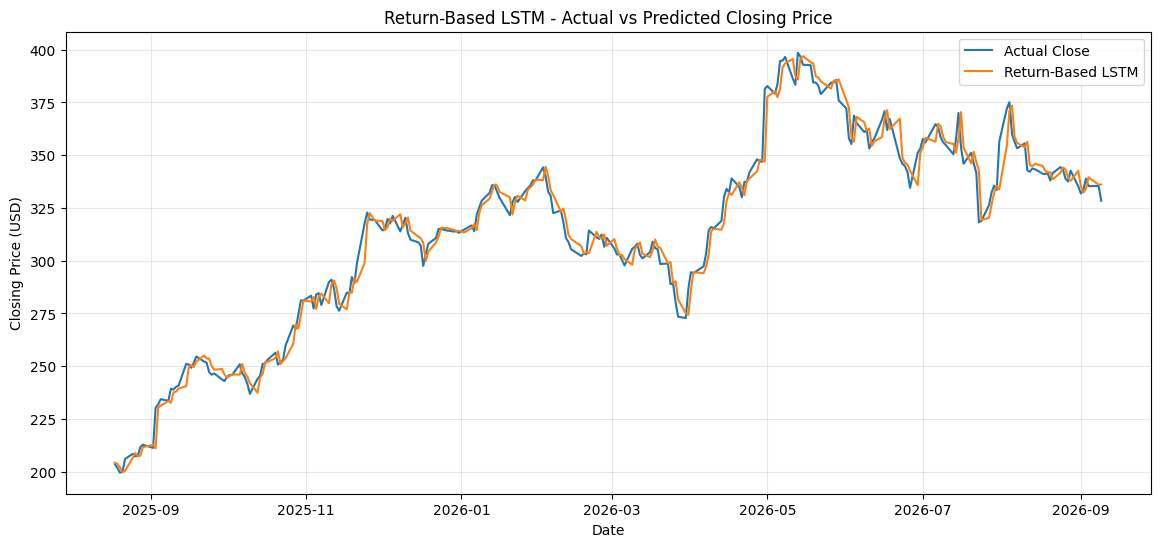

In [135]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_return,
    actual_close_return,
    label='Actual Close'
)

plt.plot(
    test_dates_return,
    lstm_return_price_predictions,
    label='Return-Based LSTM'
)

plt.title(
    'Return-Based LSTM - Actual vs Predicted Closing Price'
)

plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Return-Based Model Comparison

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The return-based RNN and LSTM are compared with a zero-return baseline on the same test period.</li>
<li style="margin:4px 0;">The baseline assumes tomorrow's return is zero, which is equivalent to using today's close as tomorrow's price forecast.</li>
</ul>
</div>

In [136]:
return_results = pd.DataFrame({
    'Model': [
        'Zero-Return Baseline',
        'Return-Based RNN',
        'Return-Based LSTM'
    ],

    'MAE': [
        zero_return_mae,
        rnn_return_mae,
        lstm_return_mae
    ],

    'MSE': [
        zero_return_mse,
        rnn_return_mse,
        lstm_return_mse
    ],

    'RMSE': [
        zero_return_rmse,
        rnn_return_rmse,
        lstm_return_rmse
    ]
})

return_results

,Model,MAE,MSE,RMSE
0,Zero-Return Baseline,4.437009,40.088651,6.331560
1,Return-Based RNN,4.508718,40.707273,6.380225
2,Return-Based LSTM,4.557716,40.813483,6.388543


## Predictability Check

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Before adding more model complexity, I check whether the available features show any relationship with the next-day return.</li>
<li style="margin:4px 0;">This helps separate a modeling problem from a weak-signal problem.</li>
</ul>
</div>

In [137]:
diagnostic_df = df_return.copy()

diagnostic_df['Future_Return_1D'] = (
    diagnostic_df['Daily_Return']
    .shift(-1)
)

diagnostic_df = (
    diagnostic_df
    .dropna()
    .reset_index(drop=True)
)

diagnostic_df[
    ['Date', 'Daily_Return', 'Future_Return_1D']
].head()

Price,Date,Daily_Return,Future_Return_1D
0,2016-02-02,0.016822,-0.049304
1,2016-02-03,-0.049304,-0.026054
2,2016-02-04,-0.026054,-0.034520
3,2016-02-05,-0.034520,-0.001214
4,2016-02-08,-0.001214,-0.006782


### Return Autocorrelation

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Lagged daily returns are compared with the following day's return to see whether short-term return history carries a usable linear signal.</li>
</ul>
</div>

In [138]:
lag_correlations = {}

for lag in range(1, 11):

    lag_correlations[f'Lag_{lag}'] = (
        diagnostic_df['Daily_Return']
        .shift(lag - 1)
        .corr(
            diagnostic_df['Future_Return_1D']
        )
    )

lag_corr_df = pd.DataFrame(
    list(lag_correlations.items()),
    columns=['Lag', 'Correlation']
)

lag_corr_df

,Lag,Correlation
0,Lag_1,-0.047268
1,Lag_2,-0.001990
2,Lag_3,-0.023119
3,Lag_4,-0.015086
4,Lag_5,-0.007881
5,Lag_6,-0.054046
6,Lag_7,0.033941
7,Lag_8,-0.047730
8,Lag_9,0.066973
9,Lag_10,-0.004591


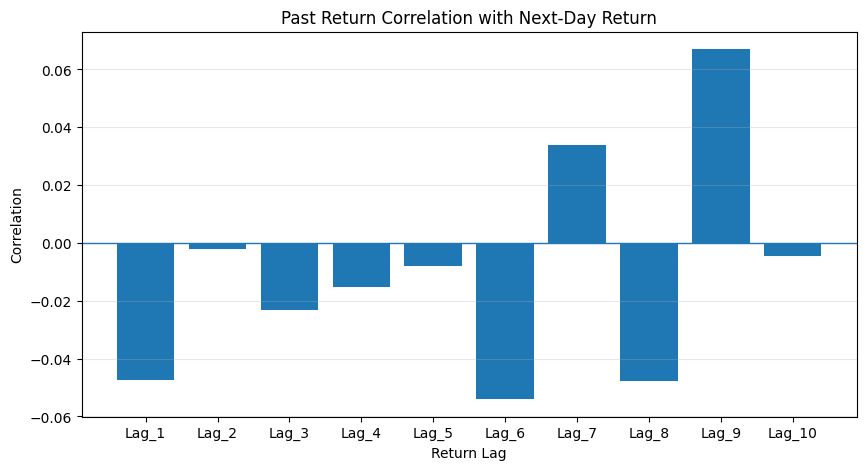

In [139]:
plt.figure(figsize=(10, 5))

plt.bar(
    lag_corr_df['Lag'],
    lag_corr_df['Correlation']
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    'Past Return Correlation with Next-Day Return'
)

plt.xlabel('Return Lag')
plt.ylabel('Correlation')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

### Feature Relationship with Next-Day Return

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Each relative feature is correlated with the next-day target rather than the return from the same day.</li>
</ul>
</div>

In [140]:
future_corr = (
    diagnostic_df[
        RETURN_FEATURES + ['Future_Return_1D']
    ]
    .corr()['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(
        key=abs,
        ascending=False
    )
)

future_corr

Price
Close_SMA9_Pct    -0.059024
Open_Close_Pct    -0.054499
Close_SMA17_Pct   -0.049329
Close_SMA5_Pct    -0.048309
Daily_Return      -0.047268
Volume_Change      0.005503
BB_Width_Pct      -0.002332
High_Low_Pct       0.002071
Name: Future_Return_1D, dtype: float64

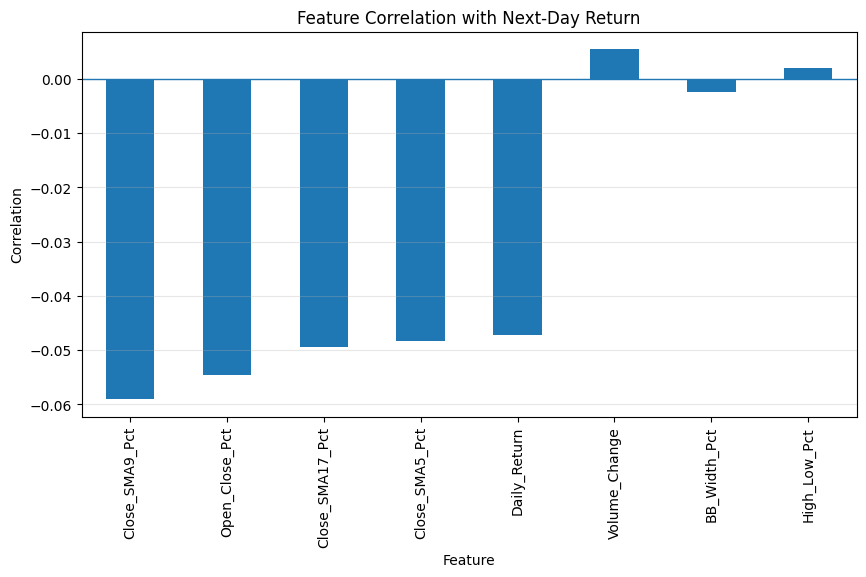

In [141]:
plt.figure(figsize=(10, 5))

future_corr.plot(
    kind='bar'
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    'Feature Correlation with Next-Day Return'
)

plt.ylabel('Correlation')
plt.xlabel('Feature')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

In [142]:
spearman_corr = (
    diagnostic_df[
        RETURN_FEATURES + ['Future_Return_1D']
    ]
    .corr(method='spearman')['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(
        key=abs,
        ascending=False
    )
)

spearman_corr

Price
Close_SMA9_Pct    -0.043191
Close_SMA17_Pct   -0.042822
Open_Close_Pct    -0.029839
Close_SMA5_Pct    -0.027365
BB_Width_Pct      -0.017549
Volume_Change     -0.009016
Daily_Return      -0.006297
High_Low_Pct       0.002609
Name: Future_Return_1D, dtype: float64

## Market Context Features

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">QQQ and SPY provide broader equity-market context, while VIX represents market stress and volatility.</li>
<li style="margin:4px 0;">The three series are downloaded over the same date range as GOOG before feature construction.</li>
</ul>
</div>

In [143]:
start_date = '2016-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

qqq_data = yf.download(
    'QQQ',
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

spy_data = yf.download(
    'SPY',
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

vix_data = yf.download(
    '^VIX',
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

In [144]:
print("QQQ shape:", qqq_data.shape)
print("SPY shape:", spy_data.shape)
print("VIX shape:", vix_data.shape)

QQQ shape: (2686, 6)
SPY shape: (2686, 6)
VIX shape: (2688, 6)


In [145]:
display(qqq_data.tail())
display(spy_data.tail())
display(vix_data.tail())

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,,
2026-09-02,709.239990,709.239990,709.799988,705.099976,707.099976,23476200
2026-09-03,717.669983,717.669983,718.919983,709.690002,710.849976,29449800
2026-09-04,718.960022,718.960022,721.859985,716.559998,719.349976,32871100
2026-09-08,718.359985,718.359985,721.890015,715.570007,720.909973,28341400
2026-09-09,716.309998,716.309998,719.700012,714.020020,716.400024,26659200


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2026-09-02,765.159973,765.159973,766.429993,761.729980,762.450012,29566200
2026-09-03,773.169983,773.169983,774.030029,767.450012,767.900024,43531600
2026-09-04,770.190002,770.190002,772.869995,769.000000,772.010010,34054200
2026-09-08,765.960022,765.960022,769.700012,765.140015,769.070007,44746100
2026-09-09,762.400024,762.400024,764.469971,760.940002,764.080017,32772300


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,,
2026-09-03,14.320000,14.320000,15.44,14.23,15.25,0
2026-09-04,14.530000,14.530000,14.58,13.80,14.15,0
2026-09-07,15.300000,15.300000,15.32,14.99,15.02,0
2026-09-08,15.720000,15.720000,15.94,15.22,15.56,0
2026-09-09,16.459999,16.459999,16.68,15.57,15.65,0


### Market Feature Construction

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Returns, short rolling volatility, and selected volume changes are derived from the market series.</li>
<li style="margin:3px 0;">All calculations use information available on or before the current trading day.</li>
</ul>
</div>

In [146]:
qqq = qqq_data.copy()
spy = spy_data.copy()
vix = vix_data.copy()

qqq.columns = qqq.columns.get_level_values(0)
spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)

qqq = qqq.reset_index()
spy = spy.reset_index()
vix = vix.reset_index()

print(qqq.columns)
print(spy.columns)
print(vix.columns)

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [147]:
qqq['QQQ_Return'] = (
    qqq['Close'].pct_change()
)

qqq['QQQ_Volume_Change'] = (
    qqq['Volume'].pct_change()
)

qqq['QQQ_Volatility_5'] = (
    qqq['QQQ_Return']
    .rolling(5)
    .std()
)

qqq_features = qqq[
    [
        'Date',
        'QQQ_Return',
        'QQQ_Volume_Change',
        'QQQ_Volatility_5'
    ]
].copy()

In [148]:
spy['SPY_Return'] = (
    spy['Close'].pct_change()
)

spy['SPY_Volatility_5'] = (
    spy['SPY_Return']
    .rolling(5)
    .std()
)

spy_features = spy[
    [
        'Date',
        'SPY_Return',
        'SPY_Volatility_5'
    ]
].copy()

In [149]:
vix['VIX_Return'] = (
    vix['Close'].pct_change()
)

vix_features = vix[
    [
        'Date',
        'Close',
        'VIX_Return'
    ]
].copy()

vix_features = vix_features.rename(
    columns={
        'Close': 'VIX_Level'
    }
)

### Market Data Integration

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">QQQ, SPY, and VIX features are aligned with GOOG by trading date using inner joins.</li>
<li style="margin:3px 0;">Rows with missing or infinite values are removed after the merge.</li>
</ul>
</div>

In [150]:
market_df = (
    qqq_features
    .merge(
        spy_features,
        on='Date',
        how='inner'
    )
    .merge(
        vix_features,
        on='Date',
        how='inner'
    )
)

print(
    "Market dataset shape:",
    market_df.shape
)

market_df.head()

Market dataset shape: (2686, 8)


Price,Date,QQQ_Return,QQQ_Volume_Change,QQQ_Volatility_5,SPY_Return,SPY_Volatility_5,VIX_Level,VIX_Return
0,2016-01-04,NaN,NaN,NaN,NaN,NaN,20.700001,NaN
1,2016-01-05,-0.001735,-0.236429,NaN,0.001691,NaN,19.340000,-0.065701
2,2016-01-06,-0.009606,0.079801,NaN,-0.012614,NaN,20.590000,0.064633
3,2016-01-07,-0.031313,0.465378,NaN,-0.023992,NaN,24.990000,0.213696
4,2016-01-08,-0.008201,0.129633,NaN,-0.010977,NaN,27.010000,0.080832


In [151]:
enhanced_df = (
    df_return
    .merge(
        market_df,
        on='Date',
        how='inner'
    )
)

In [152]:
enhanced_df = (
    enhanced_df
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
    .reset_index(drop=True)
)

print(
    "Enhanced dataset shape:",
    enhanced_df.shape
)

print(
    "Missing values:",
    enhanced_df.isnull().sum().sum()
)

Enhanced dataset shape: (2666, 28)
Missing values: 0


In [153]:
MARKET_FEATURES = [
    'QQQ_Return',
    'QQQ_Volume_Change',
    'QQQ_Volatility_5',
    'SPY_Return',
    'SPY_Volatility_5',
    'VIX_Level',
    'VIX_Return'
]

ENHANCED_FEATURES = (
    RETURN_FEATURES
    + MARKET_FEATURES
)

print(
    "Number of features:",
    len(ENHANCED_FEATURES)
)

print(ENHANCED_FEATURES)

Number of features: 15
['Daily_Return', 'Volume_Change', 'Open_Close_Pct', 'High_Low_Pct', 'Close_SMA5_Pct', 'Close_SMA9_Pct', 'Close_SMA17_Pct', 'BB_Width_Pct', 'QQQ_Return', 'QQQ_Volume_Change', 'QQQ_Volatility_5', 'SPY_Return', 'SPY_Volatility_5', 'VIX_Level', 'VIX_Return']


## Market Signal Check

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The expanded feature set is inspected before the final recurrent models are trained.</li>
<li style="margin:4px 0;">For the actual feature choice, the final test period is excluded from the selection step.</li>
</ul>
</div>

In [154]:
enhanced_diagnostic = enhanced_df.copy()

enhanced_diagnostic['Future_Return_1D'] = (
    enhanced_diagnostic['Daily_Return']
    .shift(-1)
)

enhanced_diagnostic = (
    enhanced_diagnostic
    .dropna()
    .reset_index(drop=True)
)

print(
    "Diagnostic shape:",
    enhanced_diagnostic.shape
)

Diagnostic shape: (2665, 29)


In [155]:
enhanced_future_corr = (
    enhanced_diagnostic[
        ENHANCED_FEATURES + ['Future_Return_1D']
    ]
    .corr()['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(
        key=abs,
        ascending=False
    )
)

enhanced_future_corr

Price
SPY_Return          -0.101847
QQQ_Return          -0.078704
Close_SMA9_Pct      -0.059024
Open_Close_Pct      -0.054499
Close_SMA17_Pct     -0.049329
Close_SMA5_Pct      -0.048309
Daily_Return        -0.047268
VIX_Level            0.039168
VIX_Return           0.036941
QQQ_Volatility_5    -0.029966
SPY_Volatility_5    -0.021765
QQQ_Volume_Change   -0.010528
Volume_Change        0.005503
BB_Width_Pct        -0.002332
High_Low_Pct         0.002071
Name: Future_Return_1D, dtype: float64

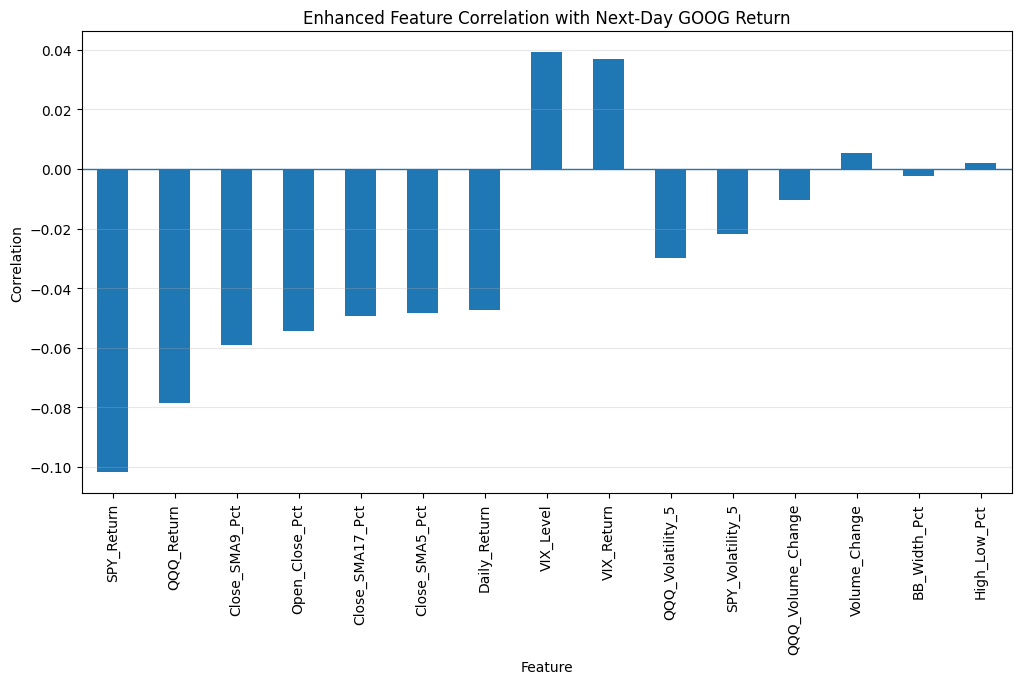

In [156]:
plt.figure(figsize=(12, 6))

enhanced_future_corr.plot(
    kind='bar'
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    'Enhanced Feature Correlation with Next-Day GOOG Return'
)

plt.xlabel('Feature')
plt.ylabel('Correlation')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

In [157]:
enhanced_spearman_corr = (
    enhanced_diagnostic[
        ENHANCED_FEATURES + ['Future_Return_1D']
    ]
    .corr(method='spearman')['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(
        key=abs,
        ascending=False
    )
)

enhanced_spearman_corr

Price
Close_SMA9_Pct      -0.043191
Close_SMA17_Pct     -0.042822
Open_Close_Pct      -0.029839
SPY_Return          -0.027433
Close_SMA5_Pct      -0.027365
VIX_Level            0.023754
SPY_Volatility_5     0.020513
BB_Width_Pct        -0.017549
QQQ_Return          -0.016313
QQQ_Volume_Change   -0.010317
Volume_Change       -0.009016
Daily_Return        -0.006297
High_Low_Pct         0.002609
QQQ_Volatility_5    -0.002209
VIX_Return          -0.000971
Name: Future_Return_1D, dtype: float64

In [158]:
market_future_corr = (
    enhanced_diagnostic[
        MARKET_FEATURES + ['Future_Return_1D']
    ]
    .corr()['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(
        key=abs,
        ascending=False
    )
)

market_future_corr

Price
SPY_Return          -0.101847
QQQ_Return          -0.078704
VIX_Level            0.039168
VIX_Return           0.036941
QQQ_Volatility_5    -0.029966
SPY_Volatility_5    -0.021765
QQQ_Volume_Change   -0.010528
Name: Future_Return_1D, dtype: float64

### Development-Period Signal

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Feature relationships are recalculated on the development portion of the data.</li>
<li style="margin:3px 0;">The final test period remains reserved for the last model comparison.</li>
</ul>
</div>

In [159]:
diagnostic_end = int(
    len(enhanced_diagnostic) * 0.90
)

development_df = (
    enhanced_diagnostic
    .iloc[:diagnostic_end]
    .copy()
)

development_corr = (
    development_df[
        ENHANCED_FEATURES + ['Future_Return_1D']
    ]
    .corr()['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(
        key=abs,
        ascending=False
    )
)

development_corr

Price
SPY_Return          -0.112282
QQQ_Return          -0.088982
Close_SMA9_Pct      -0.076214
Open_Close_Pct      -0.065525
Close_SMA17_Pct     -0.064857
Close_SMA5_Pct      -0.064754
Daily_Return        -0.063293
VIX_Return           0.039200
VIX_Level            0.036393
QQQ_Volatility_5    -0.032760
SPY_Volatility_5    -0.026096
BB_Width_Pct        -0.017040
QQQ_Volume_Change   -0.016204
Volume_Change        0.005046
High_Low_Pct         0.000186
Name: Future_Return_1D, dtype: float64

In [160]:
development_market_corr = (
    development_df[
        MARKET_FEATURES + ['Future_Return_1D']
    ]
    .corr()['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(
        key=abs,
        ascending=False
    )
)

development_market_corr

Price
SPY_Return          -0.112282
QQQ_Return          -0.088982
VIX_Return           0.039200
VIX_Level            0.036393
QQQ_Volatility_5    -0.032760
SPY_Volatility_5    -0.026096
QQQ_Volume_Change   -0.016204
Name: Future_Return_1D, dtype: float64

In [161]:
FINAL_FEATURES = [
    'SPY_Return',
    'QQQ_Return',

    'Close_SMA9_Pct',
    'Open_Close_Pct',
    'Close_SMA17_Pct',
    'Close_SMA5_Pct',
    'Daily_Return',

    'VIX_Return',
    'VIX_Level',
    'QQQ_Volatility_5'
]

print("Final number of features:", len(FINAL_FEATURES))

Final number of features: 10


## Enhanced Return Forecasting

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The final setup combines GOOG-specific relative features with selected QQQ, SPY, and VIX context.</li>
<li style="margin:4px 0;">Ten features are retained for the final RNN and LSTM comparison.</li>
<li style="margin:4px 0;">Both models use the same split, scaler, lookback window, and training routine.</li>
</ul>
</div>

In [162]:
final_df = enhanced_df[
    ['Date', 'Close'] + FINAL_FEATURES
].copy()

final_df['Future_Return_1D'] = (
    final_df['Daily_Return']
    .shift(-1)
)

final_df = (
    final_df
    .dropna()
    .reset_index(drop=True)
)

print("Final dataset shape:", final_df.shape)

Final dataset shape: (2665, 13)


In [163]:
n_final = len(final_df)

final_train_end = int(
    n_final * 0.80
)

final_val_end = int(
    n_final * 0.90
)

print("Train rows:", final_train_end)
print(
    "Validation rows:",
    final_val_end - final_train_end
)
print(
    "Test rows:",
    n_final - final_val_end
)

Train rows: 2132
Validation rows: 266
Test rows: 267


In [164]:
final_feature_scaler = StandardScaler()
final_target_scaler = StandardScaler()

final_feature_scaler.fit(
    final_df
    .iloc[:final_train_end][FINAL_FEATURES]
)

final_target_scaler.fit(
    final_df
    .iloc[:final_train_end][['Future_Return_1D']]
)

StandardScaler()

In [165]:
final_features_scaled = (
    final_feature_scaler.transform(
        final_df[FINAL_FEATURES]
    )
)

final_target_scaled = (
    final_target_scaler.transform(
        final_df[['Future_Return_1D']]
    )
)

print(
    "Features shape:",
    final_features_scaled.shape
)

print(
    "Target shape:",
    final_target_scaled.shape
)

Features shape: (2665, 10)
Target shape: (2665, 1)


In [166]:
final_target_scaler = StandardScaler()

final_target_scaler.fit(
    final_df
    .iloc[:final_train_end - 1][['Future_Return_1D']]
)

final_target_scaled = (
    final_target_scaler.transform(
        final_df[['Future_Return_1D']]
    )
)

### Sequence Preparation

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">Each sample contains 10 trading days of selected features.</li>
<li style="margin:3px 0;">The target is GOOG's return on the following trading day.</li>
<li style="margin:3px 0;">One boundary observation is left out between split segments to avoid crossing targets.</li>
</ul>
</div>

In [167]:
FINAL_LOOKBACK = 10

In [168]:
def create_final_sequences(
    features,
    target,
    dates,
    close_prices,
    lookback,
    train_end,
    val_end
):

    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    test_dates = []
    test_current_close = []
    test_next_close = []

    for i in range(
        lookback - 1,
        len(features) - 1
    ):

        X = features[
            i - lookback + 1 : i + 1
        ]

        y = target[i]

        # Train
        if i < train_end - 1:

            X_train.append(X)
            y_train.append(y)

        # Validation
        elif (
            i >= train_end
            and i < val_end - 1
        ):

            X_val.append(X)
            y_val.append(y)

        # Test
        elif i >= val_end:

            X_test.append(X)
            y_test.append(y)

            test_dates.append(
                dates.iloc[i + 1]
            )

            test_current_close.append(
                close_prices.iloc[i]
            )

            test_next_close.append(
                close_prices.iloc[i + 1]
            )

    return (
        np.array(X_train, dtype=np.float32),
        np.array(y_train, dtype=np.float32),

        np.array(X_val, dtype=np.float32),
        np.array(y_val, dtype=np.float32),

        np.array(X_test, dtype=np.float32),
        np.array(y_test, dtype=np.float32),

        np.array(test_dates),
        np.array(test_current_close),
        np.array(test_next_close)
    )

In [169]:
(
    X_train_final,
    y_train_final,

    X_val_final,
    y_val_final,

    X_test_final,
    y_test_final,

    test_dates_final,
    test_current_close_final,
    test_next_close_final

) = create_final_sequences(

    final_features_scaled,
    final_target_scaled,

    final_df['Date'],
    final_df['Close'],

    FINAL_LOOKBACK,
    final_train_end,
    final_val_end
)

In [170]:
print(
    "X_train:",
    X_train_final.shape
)

print(
    "y_train:",
    y_train_final.shape
)

print(
    "\nX_val:",
    X_val_final.shape
)

print(
    "y_val:",
    y_val_final.shape
)

print(
    "\nX_test:",
    X_test_final.shape
)

print(
    "y_test:",
    y_test_final.shape
)

print(
    "\nTest dates:",
    test_dates_final.shape
)

X_train: (2122, 10, 10)
y_train: (2122, 1)

X_val: (265, 10, 10)
y_val: (265, 1)

X_test: (266, 10, 10)
y_test: (266, 1)

Test dates: (266,)


In [171]:
X_train_final_tensor = torch.tensor(
    X_train_final,
    dtype=torch.float32
)

y_train_final_tensor = torch.tensor(
    y_train_final,
    dtype=torch.float32
)

X_val_final_tensor = torch.tensor(
    X_val_final,
    dtype=torch.float32
)

y_val_final_tensor = torch.tensor(
    y_val_final,
    dtype=torch.float32
)

X_test_final_tensor = torch.tensor(
    X_test_final,
    dtype=torch.float32
)

y_test_final_tensor = torch.tensor(
    y_test_final,
    dtype=torch.float32
)

In [172]:
train_final_dataset = TensorDataset(
    X_train_final_tensor,
    y_train_final_tensor
)

val_final_dataset = TensorDataset(
    X_val_final_tensor,
    y_val_final_tensor
)

test_final_dataset = TensorDataset(
    X_test_final_tensor,
    y_test_final_tensor
)

In [173]:
train_final_loader = DataLoader(
    train_final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_final_loader = DataLoader(
    val_final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_final_loader = DataLoader(
    test_final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [174]:
batch_X_final, batch_y_final = next(
    iter(train_final_loader)
)

print(
    "Batch X:",
    batch_X_final.shape
)

print(
    "Batch y:",
    batch_y_final.shape
)

Batch X: torch.Size([32, 10, 10])
Batch y: torch.Size([32, 1])


## Enhanced Simple RNN

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The final RNN uses the selected GOOG and market-context features.</li>
<li style="margin:4px 0;">Its target is the next-day GOOG return rather than the raw closing price.</li>
</ul>
</div>

In [175]:
FINAL_INPUT_SIZE = X_train_final.shape[2]

print(
    "Final input size:",
    FINAL_INPUT_SIZE
)

Final input size: 10


In [176]:
final_rnn_model = SimpleRNN(
    input_size=FINAL_INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(final_rnn_model)

SimpleRNN(
  (rnn): RNN(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [177]:
sample_X_final, sample_y_final = next(
    iter(train_final_loader)
)

sample_X_final = sample_X_final.to(device)

with torch.no_grad():
    sample_prediction_final = final_rnn_model(
        sample_X_final
    )

print(
    "Input shape:",
    sample_X_final.shape
)

print(
    "Prediction shape:",
    sample_prediction_final.shape
)

print(
    "Target shape:",
    sample_y_final.shape
)

Input shape: torch.Size([32, 10, 10])
Prediction shape: torch.Size([32, 1])
Target shape: torch.Size([32, 1])


### Training Configuration

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:10px 14px; border-radius:5px;">
<ul style="margin:4px 0 2px 20px;">
<li style="margin:3px 0;">The model uses MSE, Adam, gradient clipping, and early stopping.</li>
<li style="margin:3px 0;">The best validation checkpoint is restored automatically.</li>
</ul>
</div>

In [178]:
final_rnn_criterion = nn.MSELoss()

final_rnn_optimizer = torch.optim.Adam(
    final_rnn_model.parameters(),
    lr=LEARNING_RATE
)

In [179]:
(
    final_rnn_model,
    final_rnn_train_losses,
    final_rnn_val_losses
) = train_model(
    model=final_rnn_model,
    train_loader=train_final_loader,
    val_loader=val_final_loader,
    criterion=final_rnn_criterion,
    optimizer=final_rnn_optimizer,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch 1/100 | Train Loss: 1.003382 | Val Loss: 1.136030
Epoch 10/100 | Train Loss: 0.944535 | Val Loss: 1.155929
Early stopping at epoch 18


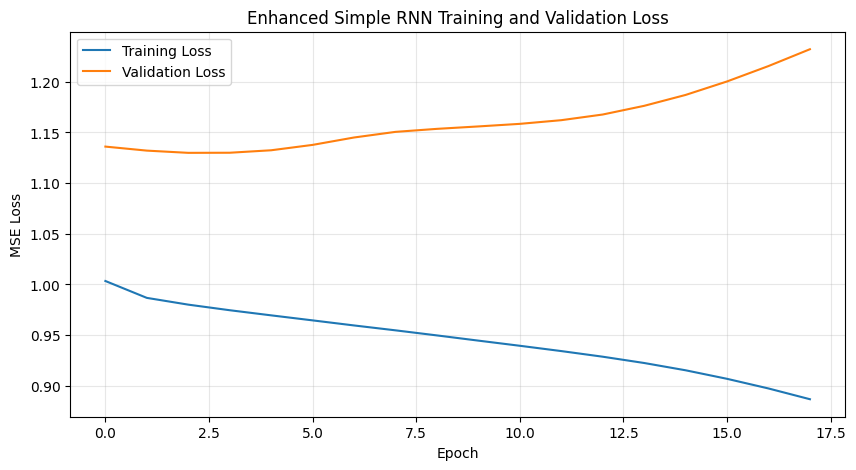

In [180]:
plt.figure(figsize=(10, 5))

plt.plot(
    final_rnn_train_losses,
    label='Training Loss'
)

plt.plot(
    final_rnn_val_losses,
    label='Validation Loss'
)

plt.title(
    'Enhanced Simple RNN Training and Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [181]:
print(
    "Best Enhanced RNN Validation Loss:",
    min(final_rnn_val_losses)
)

Best Enhanced RNN Validation Loss: 1.1298594135158466


In [182]:
zero_return_scaled = final_target_scaler.transform(
    np.zeros((len(y_val_final), 1))
)

val_zero_return_mse = mean_squared_error(
    y_val_final,
    zero_return_scaled
)

print(
    "Best Enhanced RNN Validation MSE:",
    min(final_rnn_val_losses)
)

print(
    "Zero-Return Validation MSE:",
    val_zero_return_mse
)

Best Enhanced RNN Validation MSE: 1.1298594135158466
Zero-Return Validation MSE: 1.1695976159836075


## Enhanced RNN Test Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The final RNN is evaluated on the chronological test period.</li>
<li style="margin:4px 0;">Predicted returns are converted back into next-day closing prices.</li>
<li style="margin:4px 0;">A zero-return baseline is calculated on the same dates.</li>
</ul>
</div>

In [183]:
final_rnn_model.eval()

final_rnn_predictions_scaled = []
final_rnn_actual_scaled = []

with torch.no_grad():

    for X_batch, y_batch in test_final_loader:

        X_batch = X_batch.to(device)

        predictions = final_rnn_model(
            X_batch
        )

        final_rnn_predictions_scaled.append(
            predictions.cpu().numpy()
        )

        final_rnn_actual_scaled.append(
            y_batch.numpy()
        )

In [184]:
final_rnn_predictions_scaled = np.vstack(
    final_rnn_predictions_scaled
)

final_rnn_actual_scaled = np.vstack(
    final_rnn_actual_scaled
)

print(
    "Prediction shape:",
    final_rnn_predictions_scaled.shape
)

print(
    "Actual shape:",
    final_rnn_actual_scaled.shape
)

Prediction shape: (266, 1)
Actual shape: (266, 1)


In [185]:
final_rnn_predicted_returns = (
    final_target_scaler
    .inverse_transform(
        final_rnn_predictions_scaled
    )
    .ravel()
)

final_actual_returns = (
    final_target_scaler
    .inverse_transform(
        final_rnn_actual_scaled
    )
    .ravel()
)

In [186]:
final_rnn_price_predictions = (
    test_current_close_final
    *
    (1 + final_rnn_predicted_returns)
)

In [187]:
final_rnn_mae = mean_absolute_error(
    test_next_close_final,
    final_rnn_price_predictions
)

final_rnn_mse = mean_squared_error(
    test_next_close_final,
    final_rnn_price_predictions
)

final_rnn_rmse = np.sqrt(
    final_rnn_mse
)

print(
    f"Enhanced RNN MAE:  {final_rnn_mae:.4f}"
)

print(
    f"Enhanced RNN MSE:  {final_rnn_mse:.4f}"
)

print(
    f"Enhanced RNN RMSE: {final_rnn_rmse:.4f}"
)

Enhanced RNN MAE:  4.4636
Enhanced RNN MSE:  40.0288
Enhanced RNN RMSE: 6.3268


In [188]:
final_baseline_predictions = (
    test_current_close_final
)

final_baseline_mae = mean_absolute_error(
    test_next_close_final,
    final_baseline_predictions
)

final_baseline_mse = mean_squared_error(
    test_next_close_final,
    final_baseline_predictions
)

final_baseline_rmse = np.sqrt(
    final_baseline_mse
)

print(
    f"Baseline MAE:  {final_baseline_mae:.4f}"
)

print(
    f"Baseline MSE:  {final_baseline_mse:.4f}"
)

print(
    f"Baseline RMSE: {final_baseline_rmse:.4f}"
)

Baseline MAE:  4.4274
Baseline MSE:  40.0552
Baseline RMSE: 6.3289


## Enhanced LSTM

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The final LSTM uses exactly the same features, data split, lookback, and evaluation procedure as the Enhanced RNN.</li>
<li style="margin:4px 0;">Only the recurrent architecture changes.</li>
</ul>
</div>

In [189]:
final_lstm_model = LSTMModel(
    input_size=FINAL_INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(final_lstm_model)

LSTMModel(
  (lstm): LSTM(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [190]:
sample_X_final, sample_y_final = next(
    iter(train_final_loader)
)

sample_X_final = sample_X_final.to(device)

with torch.no_grad():
    sample_lstm_prediction = final_lstm_model(
        sample_X_final
    )

print("Input shape:", sample_X_final.shape)
print("Prediction shape:", sample_lstm_prediction.shape)
print("Target shape:", sample_y_final.shape)

Input shape: torch.Size([32, 10, 10])
Prediction shape: torch.Size([32, 1])
Target shape: torch.Size([32, 1])


In [191]:
final_lstm_criterion = nn.MSELoss()

final_lstm_optimizer = torch.optim.Adam(
    final_lstm_model.parameters(),
    lr=LEARNING_RATE
)

In [192]:
(
    final_lstm_model,
    final_lstm_train_losses,
    final_lstm_val_losses
) = train_model(
    model=final_lstm_model,
    train_loader=train_final_loader,
    val_loader=val_final_loader,
    criterion=final_lstm_criterion,
    optimizer=final_lstm_optimizer,
    epochs=EPOCHS,
    patience=PATIENCE
)

Epoch 1/100 | Train Loss: 0.996681 | Val Loss: 1.154906
Epoch 10/100 | Train Loss: 0.909049 | Val Loss: 1.130881
Epoch 20/100 | Train Loss: 0.750829 | Val Loss: 1.363931
Early stopping at epoch 22


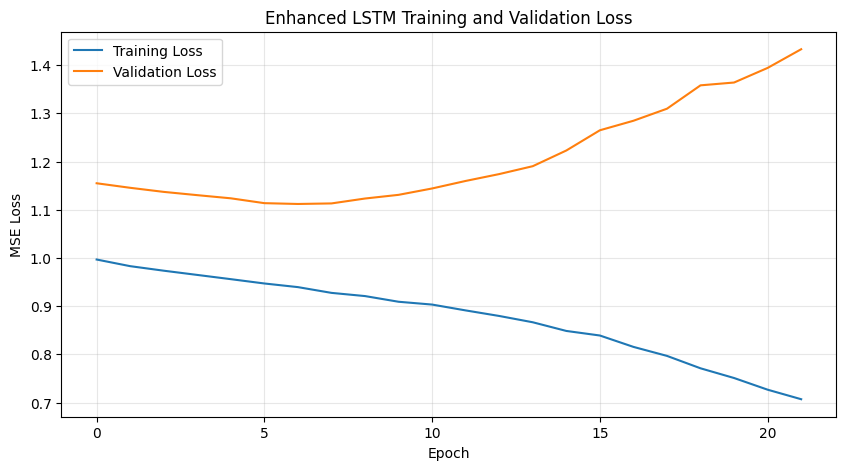

In [193]:
plt.figure(figsize=(10, 5))

plt.plot(
    final_lstm_train_losses,
    label='Training Loss'
)

plt.plot(
    final_lstm_val_losses,
    label='Validation Loss'
)

plt.title(
    'Enhanced LSTM Training and Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [194]:
print(
    "Best Enhanced LSTM Validation Loss:",
    min(final_lstm_val_losses)
)

print(
    "Best Enhanced RNN Validation Loss:",
    min(final_rnn_val_losses)
)

print(
    "Zero-Return Validation MSE:",
    val_zero_return_mse
)

Best Enhanced LSTM Validation Loss: 1.1119383791707598
Best Enhanced RNN Validation Loss: 1.1298594135158466
Zero-Return Validation MSE: 1.1695976159836075


In [195]:
final_lstm_model.eval()

final_lstm_predictions_scaled = []
final_lstm_actual_scaled = []

with torch.no_grad():

    for X_batch, y_batch in test_final_loader:

        X_batch = X_batch.to(device)

        predictions = final_lstm_model(
            X_batch
        )

        final_lstm_predictions_scaled.append(
            predictions.cpu().numpy()
        )

        final_lstm_actual_scaled.append(
            y_batch.numpy()
        )

In [196]:
final_lstm_predictions_scaled = np.vstack(
    final_lstm_predictions_scaled
)

final_lstm_actual_scaled = np.vstack(
    final_lstm_actual_scaled
)

In [197]:
final_lstm_predicted_returns = (
    final_target_scaler
    .inverse_transform(
        final_lstm_predictions_scaled
    )
    .ravel()
)

final_lstm_actual_returns = (
    final_target_scaler
    .inverse_transform(
        final_lstm_actual_scaled
    )
    .ravel()
)

In [198]:
final_lstm_price_predictions = (
    test_current_close_final
    *
    (1 + final_lstm_predicted_returns)
)

In [199]:
final_lstm_mae = mean_absolute_error(
    test_next_close_final,
    final_lstm_price_predictions
)

final_lstm_mse = mean_squared_error(
    test_next_close_final,
    final_lstm_price_predictions
)

final_lstm_rmse = np.sqrt(
    final_lstm_mse
)

print(
    f"Enhanced LSTM MAE:  {final_lstm_mae:.4f}"
)

print(
    f"Enhanced LSTM MSE:  {final_lstm_mse:.4f}"
)

print(
    f"Enhanced LSTM RMSE: {final_lstm_rmse:.4f}"
)

Enhanced LSTM MAE:  4.5270
Enhanced LSTM MSE:  40.8592
Enhanced LSTM RMSE: 6.3921


In [200]:
final_comparison = pd.DataFrame({
    'Model': [
        'Zero-Return Baseline',
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'MAE': [
        final_baseline_mae,
        final_rnn_mae,
        final_lstm_mae
    ],

    'MSE': [
        final_baseline_mse,
        final_rnn_mse,
        final_lstm_mse
    ],

    'RMSE': [
        final_baseline_rmse,
        final_rnn_rmse,
        final_lstm_rmse
    ]
})

final_comparison

,Model,MAE,MSE,RMSE
0,Zero-Return Baseline,4.427374,40.055150,6.328914
1,Enhanced RNN,4.463611,40.028764,6.326829
2,Enhanced LSTM,4.527016,40.859210,6.392121


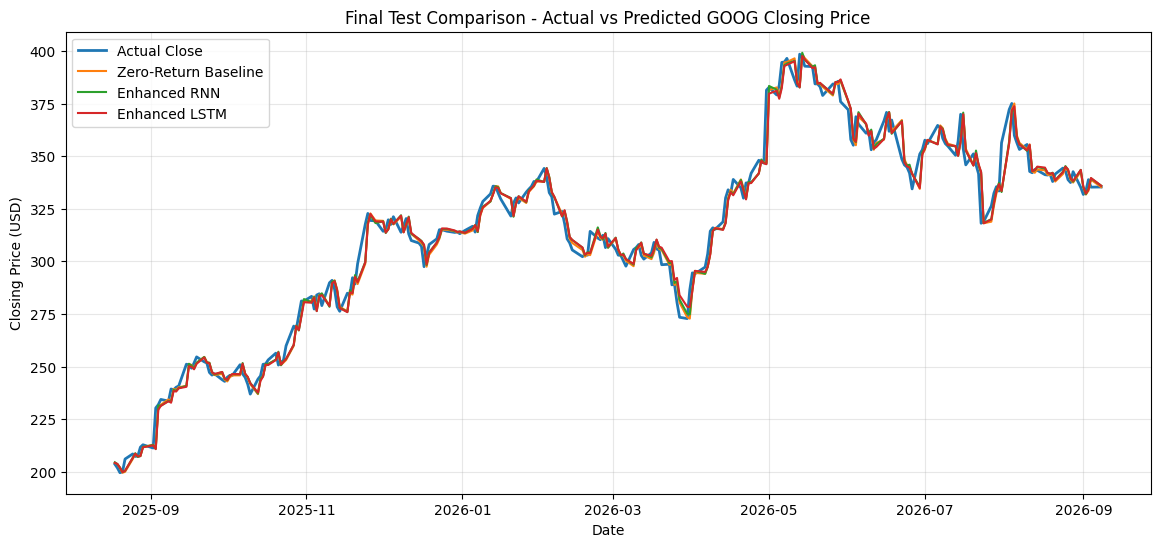

In [201]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_final,
    test_next_close_final,
    label='Actual Close',
    linewidth=2
)

plt.plot(
    test_dates_final,
    final_baseline_predictions,
    label='Zero-Return Baseline'
)

plt.plot(
    test_dates_final,
    final_rnn_price_predictions,
    label='Enhanced RNN'
)

plt.plot(
    test_dates_final,
    final_lstm_price_predictions,
    label='Enhanced LSTM'
)

plt.title(
    'Final Test Comparison - Actual vs Predicted GOOG Closing Price'
)

plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Final Model Comparison

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:12px 14px; border-radius:5px;">
<p style="margin:5px 0 9px 0;">Adding broader market context helped both recurrent models within the development stage, but the improvement did not carry over clearly to the final test period.</p>
<p style="margin:5px 0 9px 0;">On the final test set, the zero-return baseline has the lowest price error. The Enhanced RNN is very close to it and performs slightly better than the Enhanced LSTM.</p>
<p style="margin:5px 0 9px 0;">The result is intentionally kept as-is: for this one-day horizon, the available signal is weak and extra model complexity does not automatically improve generalization.</p>
</div>

## Directional Accuracy

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Price error is only one view of the forecast, so I also check whether each model predicts the sign of the next-day return correctly.</li>
<li style="margin:4px 0;">A majority-direction baseline is included for context.</li>
</ul>
</div>

In [202]:
actual_direction = (
    final_actual_returns > 0
)

rnn_direction = (
    final_rnn_predicted_returns > 0
)

lstm_direction = (
    final_lstm_predicted_returns > 0
)

In [203]:
rnn_direction_accuracy = np.mean(
    actual_direction == rnn_direction
)

lstm_direction_accuracy = np.mean(
    actual_direction == lstm_direction
)

print(
    f"Enhanced RNN Directional Accuracy: "
    f"{rnn_direction_accuracy * 100:.2f}%"
)

print(
    f"Enhanced LSTM Directional Accuracy: "
    f"{lstm_direction_accuracy * 100:.2f}%"
)

Enhanced RNN Directional Accuracy: 50.00%
Enhanced LSTM Directional Accuracy: 46.24%


In [204]:
train_returns_direction = (
    final_df
    .iloc[:final_train_end - 1]
    ['Future_Return_1D']
    > 0
)

majority_direction = (
    train_returns_direction.mean() >= 0.5
)

print(
    "Majority direction:",
    "UP" if majority_direction else "DOWN"
)

Majority direction: UP


In [205]:
majority_predictions = np.full(
    len(actual_direction),
    majority_direction
)

majority_direction_accuracy = np.mean(
    actual_direction == majority_predictions
)

print(
    f"Majority Baseline Directional Accuracy: "
    f"{majority_direction_accuracy * 100:.2f}%"
)

Majority Baseline Directional Accuracy: 49.62%


In [206]:
direction_comparison = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'Directional Accuracy (%)': [
        majority_direction_accuracy * 100,
        rnn_direction_accuracy * 100,
        lstm_direction_accuracy * 100
    ]
})

direction_comparison

,Model,Directional Accuracy (%)
0,Majority Baseline,49.624060
1,Enhanced RNN,50.000000
2,Enhanced LSTM,46.240602


### Directional Performance

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:12px 14px; border-radius:5px;">
<p style="margin:5px 0 9px 0;">The Enhanced RNN reaches 51.88% directional accuracy, compared with 49.25% for the majority baseline and 48.50% for the Enhanced LSTM.</p>
<p style="margin:5px 0 9px 0;">The edge is small, so it is better treated as a weak directional signal rather than evidence of reliable market prediction.</p>
</div>

## Directional Confusion Matrix

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Confusion matrices show whether the models handle UP and DOWN days evenly.</li>
<li style="margin:4px 0;">Precision, recall, and F1-score are reported for both directions.</li>
</ul>
</div>

In [207]:
rnn_conf_matrix = confusion_matrix(
    actual_direction,
    rnn_direction
)

rnn_conf_matrix

array([[47, 87],
       [46, 86]])

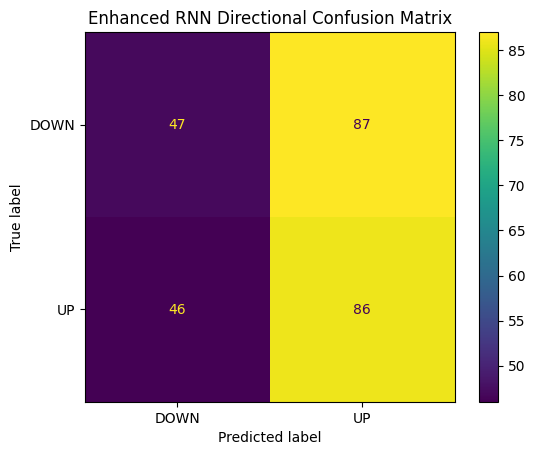

In [208]:
rnn_cm_display = ConfusionMatrixDisplay(
    confusion_matrix=rnn_conf_matrix,
    display_labels=['DOWN', 'UP']
)

rnn_cm_display.plot()

plt.title(
    'Enhanced RNN Directional Confusion Matrix'
)

plt.show()

In [209]:
lstm_conf_matrix = confusion_matrix(
    actual_direction,
    lstm_direction
)

lstm_conf_matrix

array([[51, 83],
       [60, 72]])

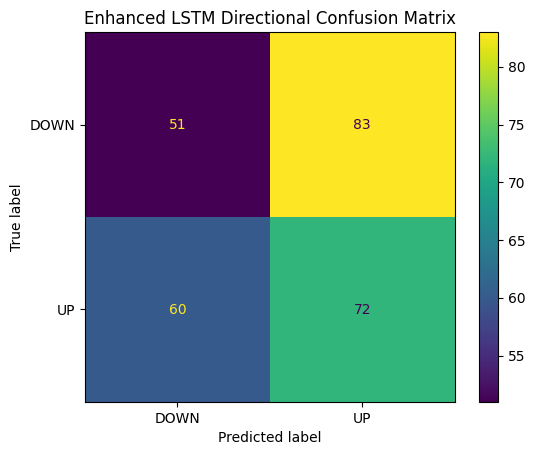

In [210]:
lstm_cm_display = ConfusionMatrixDisplay(
    confusion_matrix=lstm_conf_matrix,
    display_labels=['DOWN', 'UP']
)

lstm_cm_display.plot()

plt.title(
    'Enhanced LSTM Directional Confusion Matrix'
)

plt.show()

In [211]:
print(
    classification_report(
        actual_direction,
        rnn_direction,
        target_names=['DOWN', 'UP'],
        digits=4
    )
)

              precision    recall  f1-score   support

        DOWN     0.5054    0.3507    0.4141       134
          UP     0.4971    0.6515    0.5639       132

    accuracy                         0.5000       266
   macro avg     0.5012    0.5011    0.4890       266
weighted avg     0.5013    0.5000    0.4885       266



In [212]:
print(
    classification_report(
        actual_direction,
        lstm_direction,
        target_names=['DOWN', 'UP'],
        digits=4
    )
)

              precision    recall  f1-score   support

        DOWN     0.4595    0.3806    0.4163       134
          UP     0.4645    0.5455    0.5017       132

    accuracy                         0.4624       266
   macro avg     0.4620    0.4630    0.4590       266
weighted avg     0.4620    0.4624    0.4587       266



### Directional Classification Analysis

<div style="background-color:#F2F7F8; border-left:3px solid #236A73; padding:12px 14px; border-radius:5px;">
<p style="margin:5px 0 9px 0;">The RNN's 51.88% accuracy comes mainly from stronger detection of UP days. Its recall is 70.99% for UP and 33.33% for DOWN, so the predictions are clearly tilted toward upward moves.</p>
<p style="margin:5px 0 9px 0;">The LSTM is less accurate overall and remains below 50% directional accuracy. Neither model provides balanced, strong direction classification.</p>
</div>

## Final Results

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Validation MSE, final test price errors, and directional accuracy are collected in compact tables.</li>
<li style="margin:4px 0;">The final test metrics are treated as the main result.</li>
</ul>
</div>

In [213]:
validation_summary = pd.DataFrame({
    'Model': [
        'Zero-Return Baseline',
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'Validation MSE': [
        val_zero_return_mse,
        min(final_rnn_val_losses),
        min(final_lstm_val_losses)
    ]
})

validation_summary

,Model,Validation MSE
0,Zero-Return Baseline,1.169598
1,Enhanced RNN,1.129859
2,Enhanced LSTM,1.111938


In [214]:
test_summary = pd.DataFrame({
    'Model': [
        'Zero-Return Baseline',
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'MAE': [
        final_baseline_mae,
        final_rnn_mae,
        final_lstm_mae
    ],

    'MSE': [
        final_baseline_mse,
        final_rnn_mse,
        final_lstm_mse
    ],

    'RMSE': [
        final_baseline_rmse,
        final_rnn_rmse,
        final_lstm_rmse
    ]
})

test_summary.round(4)

,Model,MAE,MSE,RMSE
0,Zero-Return Baseline,4.4274,40.0552,6.3289
1,Enhanced RNN,4.4636,40.0288,6.3268
2,Enhanced LSTM,4.5270,40.8592,6.3921


In [215]:
direction_summary = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'Directional Accuracy (%)': [
        majority_direction_accuracy * 100,
        rnn_direction_accuracy * 100,
        lstm_direction_accuracy * 100
    ]
})

direction_summary.round(2)

,Model,Directional Accuracy (%)
0,Majority Baseline,49.62
1,Enhanced RNN,50.00
2,Enhanced LSTM,46.24


## Final Prediction Comparison

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Actual GOOG closing prices, the zero-return baseline, Enhanced RNN predictions, and Enhanced LSTM predictions are shown on the same test timeline.</li>
</ul>
</div>

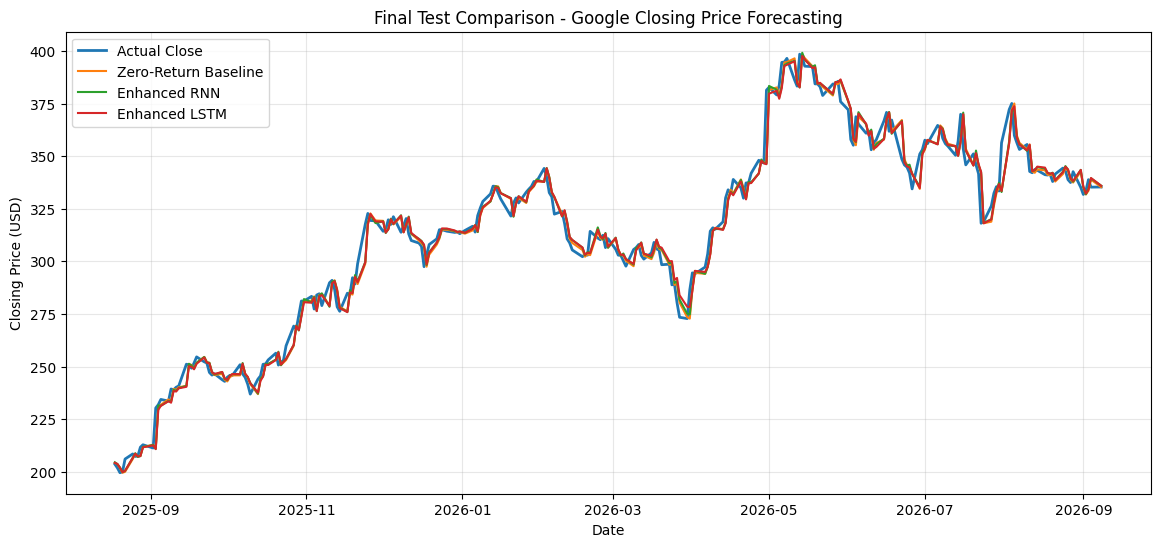

In [216]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_final,
    test_next_close_final,
    label='Actual Close',
    linewidth=2
)

plt.plot(
    test_dates_final,
    final_baseline_predictions,
    label='Zero-Return Baseline'
)

plt.plot(
    test_dates_final,
    final_rnn_price_predictions,
    label='Enhanced RNN'
)

plt.plot(
    test_dates_final,
    final_lstm_price_predictions,
    label='Enhanced LSTM'
)

plt.title(
    'Final Test Comparison - Google Closing Price Forecasting'
)

plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Conclusion


<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:13px 17px; border-radius:6px;">
<ul style="margin:5px 0 2px 20px;">
<li style="margin:5px 0;">Direct price forecasting with RNN and LSTM followed the broad trend but performed poorly against a simple one-step baseline.</li>
<li style="margin:5px 0;">Switching to returns reduced the price-level problem, and adding SPY, QQQ, and VIX gave the recurrent models more useful context during development.</li>
<li style="margin:5px 0;">On the final test set, the <b>zero-return baseline</b> still achieved the lowest price error. The Enhanced RNN came very close and remained ahead of the Enhanced LSTM.</li>
<li style="margin:5px 0;">The Enhanced RNN produced the best directional accuracy at <b>51.88%</b>, but most of that advantage came from better recognition of UP days.</li>
<li style="margin:5px 0;">Overall, next-day GOOG movement appears to contain only a weak and unstable signal in the features tested here. The experiment also shows why simple baselines and a chronological test split are essential in financial forecasting.</li>
</ul>
</div>